In [1]:
# -*- coding: utf-8 -*-

# Multi-Species Weed Recognition: 9-Class DeepWeeds Classification

This notebook keeps the original **EfficientNet-B0, MobileNetV3-Large, and ViT-Tiny** comparison, but uses the public **DeepWeeds** dataset so the experiment stays practical on Google Colab.

## Dataset and scientific protocol

DeepWeeds contains **17,509 images** covering eight invasive weed species plus one negative/background class (9 classes total). The official repository documents unique filenames in the form `YYYYMMDD-HHMMSS-ID`, where the final integer identifies the imaging instrument. The repository also provides the exact training/validation/testing label subsets used by its published 5-fold evaluation protocol.

### Scientific design choices in this notebook

- **Primary task:** 9-class weed/background image classification.
- **Label source:** the official DeepWeeds `labels.csv`; labels are not inferred from the images.
- **Grouping:** a conservative grouping key is derived from the official filename convention as **capture date + instrument ID**. If that grouping cannot support class-complete stratified folds, the code falls back to the exact capture timestamp and finally the unique image identifier.
- **Split:** one deterministic **5-fold-derived 60/20/20 geometry** is created for a practical Colab run (fold 0 = test, fold 1 = validation, folds 2–4 = train), with non-overlapping groups. This is a leakage-aware reconstruction and is **not claimed to be byte-for-byte identical to the repository's published fold CSV assignments**.
- **Model selection:** validation top-1 accuracy only. The test set is opened only after the final configuration is selected.
- **Loss:** balanced cross-entropy weights are computed from training data only.
- **Runtime mode:** the Colab-balanced profile uses a smaller pilot subset but the full available training split for final training.
- **Reproducibility:** a fixed seed, saved split manifest/checksum, saved configuration, and explicit deterministic-mode setting are recorded.

## Primary sources

- DeepWeeds GitHub repository: https://github.com/AlexOlsen/DeepWeeds
- DeepWeeds dataset DOI: https://doi.org/10.5281/zenodo.7939060
- DeepWeeds paper: https://doi.org/10.1038/s41598-018-38343-3

The dataset/repository documentation states that the images and annotations are available under **CC BY 4.0**. Use the dataset with the required attribution.


In [2]:
# Install only packages that are missing. Colab usually already includes PyTorch,
# torchvision, NumPy, pandas, scikit-learn, and matplotlib.
import importlib.util
import subprocess
import sys


def ensure_package(import_name: str, pip_name: str | None = None) -> None:
    if importlib.util.find_spec(import_name) is None:
        package = pip_name or import_name
        print(f"Installing missing package: {package}")
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", package])


ensure_package("timm", "timm>=1.0,<2.0")

import csv
import gc
import hashlib
import json
import math
import os
import platform
import random
import re
import shutil
import subprocess
import sys
import time
import warnings
from dataclasses import asdict, dataclass
from pathlib import Path
from typing import Any, Iterable, Optional

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from PIL import Image, ImageFile
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    precision_recall_fscore_support,
)
from sklearn.model_selection import StratifiedGroupKFold

from tqdm.auto import tqdm

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset
from torchvision import models, transforms
from torchvision.transforms import InterpolationMode
from torchvision.models import (
    EfficientNet_B0_Weights,
    MobileNet_V3_Large_Weights,
)
import timm

# Do not globally suppress UserWarning: warnings from image/model libraries; they can
# reveal real compatibility or data-quality problems during a research run.
ImageFile.LOAD_TRUNCATED_IMAGES = False

print("Python:", sys.version.split()[0])
print("Platform:", platform.platform())
print("PyTorch:", torch.__version__)
print("Torchvision:", __import__("torchvision").__version__)
print("NumPy:", np.__version__)
print("pandas:", pd.__version__)
print("scikit-learn:", __import__("sklearn").__version__)
print("timm:", timm.__version__)

# Keep the main experiment settings together so each run is easy to audit.
SEED = 42
DATA_ROOT = Path("/content/DeepWeeds")
WORK_ROOT = Path("/content/multi_species_weed_recognition")
RESULTS_ROOT = WORK_ROOT / "results"

for subdir in [
    RESULTS_ROOT / "metrics",
    RESULTS_ROOT / "predictions",
    RESULTS_ROOT / "checkpoints",
    RESULTS_ROOT / "figures",
    RESULTS_ROOT / "tables",
    RESULTS_ROOT / "configs",
    RESULTS_ROOT / "logs",
]:
    subdir.mkdir(parents=True, exist_ok=True)

# Dataset acquisition is handled by the dedicated Drive-first acquisition cell.
# DOWNLOAD_DATASET=True lets the notebook fetch the DeepWeeds image archive when
# neither a Drive archive/folder nor a local Colab dataset is available.
DOWNLOAD_DATASET = True
GIT_REPO = "https://github.com/AlexOlsen/DeepWeeds.git"

# Keep the image settings the same across all three architectures for a fair comparison.
IMAGE_SIZE = 224
BATCH_SIZE = 64
# Colab free runtimes commonly expose only 2 CPU cores; a small cap helps avoid
# too much worker contention on larger runtimes.
NUM_WORKERS = min(4, os.cpu_count() or 1)
PIN_MEMORY = torch.cuda.is_available()
PREFETCH_FACTOR = 2

# The default profile is designed for a normal Colab GPU while keeping the full-data
# path available. Set COMPUTE_PROFILE="full" for the uncapped experiment.
COMPUTE_PROFILE = "colab_balanced"  # Allowed profiles: "colab_balanced" or "full".
FINAL_MAX_TRAIN_SAMPLES = 120_000 if COMPUTE_PROFILE == "colab_balanced" else None
PILOT_MAX_TRAIN_SAMPLES = 6_000 if COMPUTE_PROFILE == "colab_balanced" else 10_000
PILOT_EPOCHS = 2
FINAL_HEAD_EPOCHS = 1
FINAL_FINETUNE_EPOCHS = 6
EARLY_STOPPING_PATIENCE = 2
MIN_DELTA = 1e-4

# Run two pilot learning-rate configurations per architecture. The validation set is
# never used to create loss weights or fit model parameters.
MODEL_CONFIGS = {
    "efficientnet_b0": [
        {"id": "lr1e-3", "head_lr": 1e-3, "finetune_lr": 3e-4, "weight_decay": 1e-4},
        {"id": "lr5e-4", "head_lr": 5e-4, "finetune_lr": 1e-4, "weight_decay": 1e-4},
    ],
    "mobilenet_v3_large": [
        {"id": "lr1e-3", "head_lr": 1e-3, "finetune_lr": 3e-4, "weight_decay": 1e-4},
        {"id": "lr5e-4", "head_lr": 5e-4, "finetune_lr": 1e-4, "weight_decay": 1e-4},
    ],
    "vit_tiny": [
        {"id": "lr3e-4", "head_lr": 3e-4, "finetune_lr": 1e-4, "weight_decay": 1e-2},
        {"id": "lr1e-4", "head_lr": 1e-4, "finetune_lr": 5e-5, "weight_decay": 1e-2},
    ],
}

RUN_PILOTS = True
RUN_FINAL_MODELS = True
VALIDATE_ALL_IMAGES = True
STRICT_GROUPING = True

# Reproducibility/performance trade-off:
# False keeps seeded runs reproducible at the experiment-design level while
# allowing faster cuDNN kernel selection on fixed-size inputs. Set True when
# bitwise-deterministic algorithms are required.
STRICT_DETERMINISM = False

# Keep pilot checkpoints on disk for debugging, but exclude them from
# the final ZIP by default because they are intermediate rather than headline
# scientific artifacts.
INCLUDE_PILOT_CHECKPOINTS_IN_PACKAGE = False

# The class universe below is specific to the DeepWeeds replacement dataset.
SPECIES_INFO = {
    "DW_CHAP": {"english": "Chinee apple"},
    "DW_LANT": {"english": "Lantana"},
    "DW_PARK": {"english": "Parkinsonia"},
    "DW_PART": {"english": "Parthenium"},
    "DW_PRAC": {"english": "Prickly acacia"},
    "DW_RUBV": {"english": "Rubber vine"},
    "DW_SIWE": {"english": "Siam weed"},
    "DW_SNWE": {"english": "Snake weed"},
    "DW_NEG": {"english": "Negative"},
}

SPECIES_CODES = list(SPECIES_INFO)
CLASS_TO_INDEX = {code: idx for idx, code in enumerate(SPECIES_CODES)}
INDEX_TO_CLASS = {idx: code for code, idx in CLASS_TO_INDEX.items()}

print("Classes:", len(SPECIES_CODES))
print("Device:", "cuda" if torch.cuda.is_available() else "cpu")
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
    print("CUDA capability:", torch.cuda.get_device_capability(0))

def seed_everything(seed: int) -> None:
    random.seed(seed)
    np.random.seed(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

    # Strict determinism is configurable. The default profile allows cuDNN
    # benchmarking because all model inputs have fixed spatial dimensions.
    torch.backends.cudnn.deterministic = STRICT_DETERMINISM
    torch.backends.cudnn.benchmark = not STRICT_DETERMINISM

    if hasattr(torch, "use_deterministic_algorithms"):
        torch.use_deterministic_algorithms(
            STRICT_DETERMINISM,
            warn_only=True,
        )


seed_everything(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
AMP_ENABLED = DEVICE.type == "cuda"

if AMP_ENABLED:
    try:
        AMP_DTYPE = (
            torch.bfloat16
            if torch.cuda.is_bf16_supported()
            else torch.float16
        )
    except (AttributeError, RuntimeError):
        AMP_DTYPE = torch.float16
else:
    AMP_DTYPE = torch.float32

USE_GRAD_SCALER = AMP_ENABLED and AMP_DTYPE == torch.float16

if hasattr(torch, "set_float32_matmul_precision"):
    torch.set_float32_matmul_precision("high")

print("Strict determinism:", STRICT_DETERMINISM)
print("AMP dtype:", AMP_DTYPE)
print("AMP grad scaler:", USE_GRAD_SCALER)


Python: 3.13.15
Platform: Linux-6.6.122+-x86_64-with-glibc2.35
PyTorch: 2.11.0+cu128
Torchvision: 0.26.0+cu128
NumPy: 2.1.3
pandas: 2.2.3
scikit-learn: 1.6.1
timm: 1.0.28
Classes: 9
Device: cuda
GPU: Tesla T4
CUDA capability: (7, 5)
Strict determinism: False
AMP dtype: torch.bfloat16
AMP grad scaler: False


## Dataset acquisition, Google Drive cache, ZIP download, and validation

The notebook follows a **Drive-first, archive-first** workflow for DeepWeeds.

1. Mount Google Drive and first check whether a valid DeepWeeds `images.zip` archive is already there.
2. If a valid archive exists, reuse it and extract the images into `/content` without downloading it again.
3. If an extracted DeepWeeds image folder is already available in Drive, use that as a folder fallback.
4. If neither an archive nor a dataset folder is in Drive, download the DeepWeeds `images.zip` archive from the Zenodo release used by this notebook, save the ZIP to Drive for later runs, and then extract it in Colab.
5. Download the small `labels.csv` annotation file from the official DeepWeeds GitHub repository and cache it in Drive too.
6. Validate the extracted image layout before allowing the downstream labeling, splitting, and training cells to run.

The image archive stays in Google Drive so later Colab sessions can reuse it instead of downloading the ~0.5 GB archive again.


In [3]:
# ---------------------------------------------------------------------------
# Dataset acquisition: Google Drive first, then verified DeepWeeds mirrors
# ---------------------------------------------------------------------------
# IMPORTANT:
# - A *.part file is only a temporary download artifact and is never accepted
#   as a dataset unless it passes the complete ZIP/integrity checks below.
# - The official DeepWeeds release contains 17,509 images.
# - The acquisition order is:
#       1) validated Google Drive cache
#       2) validated extracted Google Drive dataset
#       3) official DeepWeeds Google Drive image file
#       4) public Kaggle mirror
#       5) Zenodo with size + MD5 + ZIP CRC verification
# - Only a validated dataset is exposed as DATA_ROOT to downstream cells.

import hashlib
import os
import re
import shutil
import subprocess
import sys
import time
import zipfile
from pathlib import Path
from typing import Optional

import requests

DATA_SOURCE_MODE = "auto"
DOWNLOAD_DATASET = True

EXPECTED_IMAGE_COUNT = 17_509

LOCAL_DATA_ROOT = Path("/content/DeepWeeds")
DRIVE_SEARCH_ROOT = Path("/content/drive/MyDrive")

# Persistent Google Drive cache.
DRIVE_DATASET_DIR = DRIVE_SEARCH_ROOT / "DeepWeeds"
DRIVE_DATASET_ARCHIVE = DRIVE_DATASET_DIR / "DeepWeeds_images.zip"
DRIVE_DATASET_FOLDER = DRIVE_DATASET_DIR / "dataset"
DRIVE_LABELS_FILE = DRIVE_DATASET_DIR / "labels.csv"

# Temporary/local Colab paths.
LOCAL_DATASET_ARCHIVE = Path("/content/DeepWeeds_images.zip")
LOCAL_DATASET_ARCHIVE_PART = Path("/content/DeepWeeds_images.zip.part")
LOCAL_LABELS_FILE = LOCAL_DATA_ROOT / "labels.csv"
AUTO_EXTRACT_ROOT = Path("/content/DeepWeeds_extracted")
UPLOAD_WORK_ROOT = Path("/content/DeepWeeds_upload")
OFFICIAL_GIT_ROOT = Path("/content/DeepWeeds_git")
KAGGLE_WORK_ROOT = Path("/content/DeepWeeds_kaggle")

# Official/public DeepWeeds sources.
GIT_REPO = "https://github.com/AlexOlsen/DeepWeeds.git"

IMAGE_GDRIVE_FILE_ID = "1xnK3B6K6KekDI55vwJ0vnc2IGoDga9cj"

IMAGE_GDRIVE_URL = (
    "https://drive.google.com/uc?export=download&"
    f"id={IMAGE_GDRIVE_FILE_ID}"
)

IMAGE_GDRIVE_USERCONTENT_URL = (
    "https://drive.usercontent.google.com/download?"
    f"id={IMAGE_GDRIVE_FILE_ID}&export=download&confirm=t"
)

KAGGLE_DATASET = "imsparsh/deepweeds"

ZENODO_RECORD_API = "https://zenodo.org/api/records/7939060"

ZENODO_IMAGE_URL = (
    "https://zenodo.org/records/7939060/files/images.zip?download=1"
)

LABELS_URL = (
    "https://raw.githubusercontent.com/AlexOlsen/DeepWeeds/"
    "master/labels/labels.csv"
)

IMAGE_EXTENSIONS = {
    ".jpg",
    ".jpeg",
    ".png",
    ".bmp",
    ".webp",
    ".tif",
    ".tiff",
}

ANNOTATION_EXTENSIONS = {
    ".csv",
    ".tsv",
    ".json",
    ".parquet",
}

# Runtime validation cache: ZIP integrity checks would otherwise rescan the
# same ~0.5 GB archive several times during Drive-first discovery.
_ZIP_VALIDATION_CACHE: dict[tuple[str, int, int], bool] = {}


ARCHIVE_SUFFIXES = (
    ".zip",
    ".tar",
    ".tar.gz",
    ".tgz",
    ".tar.bz2",
    ".tbz2",
    ".tar.xz",
    ".txz",
)


def _mount_google_drive() -> Optional[Path]:
    """Mount Google Drive in Colab and return MyDrive."""
    drive_root = Path("/content/drive")
    mydrive = drive_root / "MyDrive"

    try:
        from google.colab import drive as colab_drive
    except ImportError:
        print("Google Colab is not available in this environment.")
        return None

    if not mydrive.exists():
        print("Mounting Google Drive...")
        colab_drive.mount(str(drive_root))

    if not mydrive.exists():
        raise RuntimeError(
            "Google Drive was mounted, but /content/drive/MyDrive was not found."
        )

    print("Google Drive ready:", mydrive)
    return mydrive


def _iter_images(root: Path):
    """Yield image files recursively without building a giant list first."""
    if not root.exists() or not root.is_dir():
        return

    for current, _dirs, files in os.walk(root):
        for name in files:
            if Path(name).suffix.lower() in IMAGE_EXTENSIONS:
                yield Path(current) / name


def _image_count(root: Path) -> int:
    return sum(1 for _ in _iter_images(root))


def _image_root(root: Path) -> Optional[Path]:
    """Resolve either root/*.jpg or root/images/*.jpg layouts."""
    if not root.exists() or not root.is_dir():
        return None

    candidates = [root]

    images_dir = root / "images"

    if images_dir.is_dir():
        candidates.insert(0, images_dir)

    for candidate in candidates:
        try:
            for p in candidate.iterdir():
                if (
                    p.is_file()
                    and p.suffix.lower() in IMAGE_EXTENSIONS
                ):
                    return candidate.resolve()
        except OSError:
            pass

    return None


def _looks_like_deepweeds_root(root: Path) -> bool:
    return _image_root(root) is not None


def _find_deepweeds_root(
    base: Path,
    max_depth: int = 6,
) -> Optional[Path]:
    """Find a directory that directly contains DeepWeeds images."""
    if not base.exists() or not base.is_dir():
        return None

    base = base.resolve()

    direct = _image_root(base)

    if direct is not None:
        return direct

    base_depth = len(base.parts)

    for current, dirs, _files in os.walk(base):
        current = Path(current)

        depth = len(current.parts) - base_depth

        if depth > max_depth:
            dirs[:] = []
            continue

        dirs[:] = [
            d
            for d in dirs
            if not d.startswith(".")
            and d not in {
                "node_modules",
                "__pycache__",
                "venv",
                ".venv",
            }
        ]

        found = _image_root(current)

        if found is not None:
            return found

    return None


def _find_labels_file(base: Path) -> Optional[Path]:
    """Find a non-empty labels.csv under a dataset tree."""
    if not base.exists() or not base.is_dir():
        return None

    preferred = [
        base / "labels.csv",
        base / "labels" / "labels.csv",
        base.parent / "labels.csv",
    ]

    for p in preferred:
        if p.is_file() and p.stat().st_size > 0:
            return p.resolve()

    for current, dirs, files in os.walk(base):
        current = Path(current)

        dirs[:] = [
            d
            for d in dirs
            if not d.startswith(".")
            and d not in {
                "node_modules",
                "__pycache__",
                "venv",
                ".venv",
            }
        ]

        for name in files:
            if name.lower() == "labels.csv":
                p = current / name

                if p.stat().st_size > 0:
                    return p.resolve()

    return None


def _copy_labels_to_local(labels_path: Path) -> Path:
    if (
        not labels_path.is_file()
        or labels_path.stat().st_size == 0
    ):
        raise RuntimeError(
            f"Invalid labels.csv: {labels_path}"
        )

    LOCAL_LABELS_FILE.parent.mkdir(
        parents=True,
        exist_ok=True,
    )

    if (
        labels_path.resolve()
        != LOCAL_LABELS_FILE.resolve()
    ):
        shutil.copy2(
            labels_path,
            LOCAL_LABELS_FILE,
        )

    return LOCAL_LABELS_FILE


def _safe_copy_file(
    src: Path,
    dst: Path,
) -> Path:
    """Atomically copy a file and never leave a false final artifact."""
    src = Path(src)
    dst = Path(dst)

    if not src.is_file():
        raise FileNotFoundError(src)

    dst.parent.mkdir(
        parents=True,
        exist_ok=True,
    )

    tmp = dst.with_name(
        dst.name + ".part"
    )

    if tmp.exists():
        tmp.unlink()

    shutil.copy2(
        src,
        tmp,
    )

    tmp.replace(dst)

    return dst


def _safe_copy_tree(
    src: Path,
    dst: Path,
) -> Path:
    """Copy a validated dataset tree to Drive."""
    src = Path(src)
    dst = Path(dst)

    if not src.is_dir():
        raise RuntimeError(
            f"Dataset directory does not exist: {src}"
        )

    if dst.exists():

        if _validate_local_image_tree(dst):
            return dst.resolve()

        shutil.rmtree(dst)

    shutil.copytree(
        src,
        dst,
    )

    return dst.resolve()


def _is_supported_archive(
    path: Path,
) -> bool:
    name = path.name.lower()

    return any(
        name.endswith(ext)
        for ext in ARCHIVE_SUFFIXES
    )


def _validate_local_image_tree(
    root: Path,
) -> bool:
    """
    Require the complete published 17,509-image DeepWeeds tree.
    """
    image_root = _image_root(root)

    if image_root is None:
        return False

    return (
        _image_count(image_root)
        == EXPECTED_IMAGE_COUNT
    )


def _validate_zip_archive(
    path: Path,
) -> bool:
    """
    Require:
      1. ZIP format
      2. exactly 17,509 images
      3. valid ZIP CRCs

    The result is memoized for an unchanged path so repeated routing checks
    do not repeatedly walk/decompress the same multi-gigabyte archive.
    """
    path = Path(path)

    if (
        not path.is_file()
        or not _is_supported_archive(path)
    ):
        return False

    stat = path.stat()
    cache_key = (
        str(path.resolve()),
        int(stat.st_size),
        int(stat.st_mtime_ns),
    )
    cached = _ZIP_VALIDATION_CACHE.get(cache_key)
    if cached is not None:
        return bool(cached)

    if not zipfile.is_zipfile(path):
        _ZIP_VALIDATION_CACHE[cache_key] = False
        return False

    try:
        with zipfile.ZipFile(
            path,
            "r",
        ) as zf:

            infos = zf.infolist()

            image_infos = [
                info
                for info in infos
                if (
                    not info.is_dir()
                    and Path(
                        info.filename.replace(
                            "\\",
                            "/",
                        )
                    ).suffix.lower()
                    in IMAGE_EXTENSIONS
                )
            ]

            if (
                len(image_infos)
                != EXPECTED_IMAGE_COUNT
            ):
                _ZIP_VALIDATION_CACHE[cache_key] = False
                return False

            bad_member = zf.testzip()

            if bad_member is not None:
                print(
                    "ZIP CRC check failed at:",
                    bad_member,
                )

                _ZIP_VALIDATION_CACHE[cache_key] = False
                return False

        _ZIP_VALIDATION_CACHE[cache_key] = True
        return True

    except (
        OSError,
        zipfile.BadZipFile,
        RuntimeError,
    ):
        _ZIP_VALIDATION_CACHE[cache_key] = False
        return False


def _cleanup_stale_downloads() -> None:
    """
    Remove the incomplete *.part artifact visible in the Colab screenshot.
    """
    if LOCAL_DATASET_ARCHIVE.exists():

        if _validate_zip_archive(
            LOCAL_DATASET_ARCHIVE
        ):
            print(
                "A complete valid local "
                "DeepWeeds ZIP already exists."
            )
            return

        print(
            "Removing invalid local ZIP:",
            LOCAL_DATASET_ARCHIVE,
        )

        LOCAL_DATASET_ARCHIVE.unlink()

    if LOCAL_DATASET_ARCHIVE_PART.exists():

        if _validate_zip_archive(
            LOCAL_DATASET_ARCHIVE_PART
        ):
            print(
                "The existing .part file is complete; "
                "promoting it to ZIP."
            )

            LOCAL_DATASET_ARCHIVE_PART.replace(
                LOCAL_DATASET_ARCHIVE
            )

            return

        size_mb = (
            LOCAL_DATASET_ARCHIVE_PART.stat().st_size
            / (1024**2)
        )

        print(
            "Removing stale/incomplete "
            "download artifact:",
            LOCAL_DATASET_ARCHIVE_PART,
            f"({size_mb:.1f} MiB)",
        )

        LOCAL_DATASET_ARCHIVE_PART.unlink()


def _find_drive_archive(
    search_root: Path,
) -> Optional[Path]:
    """Find only a strictly validated DeepWeeds ZIP in Drive."""
    if not search_root.exists():
        return None

    direct = [
        DRIVE_DATASET_ARCHIVE,
        search_root / "DeepWeeds_images.zip",
        search_root / "DeepWeeds_dataset.zip",
        (
            search_root
            / "Datasets"
            / "DeepWeeds"
            / "DeepWeeds_images.zip"
        ),
        (
            search_root
            / "datasets"
            / "DeepWeeds"
            / "DeepWeeds_images.zip"
        ),
    ]

    for candidate in direct:

        if (
            candidate.is_file()
            and _validate_zip_archive(candidate)
        ):
            return candidate.resolve()

    base_depth = len(
        search_root.resolve().parts
    )

    for current, dirs, files in os.walk(
        search_root
    ):

        current = Path(current)

        depth = (
            len(current.parts)
            - base_depth
        )

        if depth > 4:
            dirs[:] = []
            continue

        dirs[:] = [
            d
            for d in dirs
            if not d.startswith(".")
            and d not in {
                "node_modules",
                "__pycache__",
                "venv",
                ".venv",
            }
        ]

        for filename in files:

            if (
                "deepweed"
                not in filename.lower()
            ):
                continue

            candidate = (
                current / filename
            )

            if (
                _is_supported_archive(
                    candidate
                )
                and _validate_zip_archive(
                    candidate
                )
            ):
                return candidate.resolve()

    return None


def _find_drive_dataset_folder(
    search_root: Path,
) -> Optional[Path]:
    """
    Find a complete already-extracted
    DeepWeeds dataset on Drive.
    """
    candidates = [
        search_root / "DeepWeeds",
        search_root / "Datasets" / "DeepWeeds",
        search_root / "datasets" / "DeepWeeds",
        search_root / "Data" / "DeepWeeds",
        search_root / "data" / "DeepWeeds",
    ]

    for candidate in candidates:

        found = _find_deepweeds_root(
            candidate
        )

        if (
            found is not None
            and _validate_local_image_tree(
                found
            )
        ):
            return found

    return None


def _copy_archive_from_drive(
    drive_archive: Path,
) -> Path:
    """Copy a validated Drive ZIP to local storage."""
    if not _validate_zip_archive(
        drive_archive
    ):
        raise RuntimeError(
            f"Invalid Drive DeepWeeds ZIP: "
            f"{drive_archive}"
        )

    if (
        LOCAL_DATASET_ARCHIVE.exists()
        and LOCAL_DATASET_ARCHIVE.stat().st_size
        == drive_archive.stat().st_size
        and _validate_zip_archive(
            LOCAL_DATASET_ARCHIVE
        )
    ):
        return LOCAL_DATASET_ARCHIVE

    print(
        "Copying validated DeepWeeds ZIP "
        "from Google Drive..."
    )

    _safe_copy_file(
        drive_archive,
        LOCAL_DATASET_ARCHIVE,
    )

    if not _validate_zip_archive(
        LOCAL_DATASET_ARCHIVE
    ):
        raise RuntimeError(
            "Drive ZIP copy failed "
            "integrity validation."
        )

    return LOCAL_DATASET_ARCHIVE


def _safe_extract_zip(
    archive: Path,
    destination: Path,
) -> Path:
    """Extract safely and resolve the actual image root."""
    destination = Path(destination)

    destination.mkdir(
        parents=True,
        exist_ok=True,
    )

    root = destination.resolve()

    with zipfile.ZipFile(
        archive,
        "r",
    ) as zf:

        for info in zf.infolist():

            target = (
                destination
                / info.filename
            ).resolve()

            if (
                os.path.commonpath(
                    [
                        str(root),
                        str(target),
                    ]
                )
                != str(root)
            ):
                raise RuntimeError(
                    f"Unsafe ZIP member path: "
                    f"{info.filename}"
                )

        members = zf.infolist()
        for info in tqdm(
            members,
            total=len(members),
            desc="Extracting DeepWeeds ZIP",
            unit="file",
            dynamic_ncols=True,
            leave=True,
        ):
            zf.extract(
                info,
                destination,
            )

    found = _find_deepweeds_root(
        destination
    )

    if (
        found is None
        or not _validate_local_image_tree(
            found
        )
    ):
        raise RuntimeError(
            "Extracted archive does not contain "
            "all 17,509 DeepWeeds images."
        )

    return found


def _extract_or_reuse_archive(
    archive: Path,
) -> Path:

    marker = (
        AUTO_EXTRACT_ROOT
        / ".deepweeds_source.txt"
    )

    expected = (
        f"{archive.resolve()}|"
        f"{archive.stat().st_size}|"
        f"{archive.stat().st_mtime_ns}"
    )

    existing = _find_deepweeds_root(
        AUTO_EXTRACT_ROOT
    )

    if (
        existing is not None
        and marker.is_file()
    ):

        try:

            if (
                marker.read_text(
                    encoding="utf-8"
                ).strip()
                == expected
            ):

                if _validate_local_image_tree(
                    existing
                ):
                    print(
                        "Reusing validated "
                        "extraction:",
                        existing,
                    )

                    return existing

        except OSError:
            pass

    AUTO_EXTRACT_ROOT.mkdir(
        parents=True,
        exist_ok=True,
    )

    for child in list(
        AUTO_EXTRACT_ROOT.iterdir()
    ):

        if child.name == marker.name:
            continue

        if child.is_dir():
            shutil.rmtree(child)
        else:
            child.unlink()

    found = _safe_extract_zip(
        archive,
        AUTO_EXTRACT_ROOT,
    )

    marker.write_text(
        expected + "\n",
        encoding="utf-8",
    )

    print(
        "Extracted DeepWeeds image root:",
        found,
    )

    return found


def _download_labels() -> Path:
    """Download official labels.csv with an atomic local cache."""
    if (
        LOCAL_LABELS_FILE.is_file()
        and LOCAL_LABELS_FILE.stat().st_size > 0
    ):
        return LOCAL_LABELS_FILE

    tmp = LOCAL_LABELS_FILE.with_name(
        LOCAL_LABELS_FILE.name + ".part"
    )

    if tmp.exists():
        tmp.unlink()

    response = requests.get(
        LABELS_URL,
        headers={
            "User-Agent":
            "Mozilla/5.0 "
            "(Colab DeepWeeds downloader)"
        },
        timeout=(30, 120),
    )

    response.raise_for_status()

    data = response.content

    if (
        not data
        or b"Filename" not in data[:2000]
    ):
        raise RuntimeError(
            "Downloaded labels.csv does not "
            "look like the official DeepWeeds "
            "labels file."
        )

    LOCAL_LABELS_FILE.parent.mkdir(
        parents=True,
        exist_ok=True,
    )

    tmp.write_bytes(data)

    tmp.replace(
        LOCAL_LABELS_FILE
    )

    return LOCAL_LABELS_FILE


def _persist_labels_to_drive() -> None:
    DRIVE_DATASET_DIR.mkdir(
        parents=True,
        exist_ok=True,
    )

    if (
        DRIVE_LABELS_FILE.is_file()
        and DRIVE_LABELS_FILE.stat().st_size > 0
    ):
        return

    _safe_copy_file(
        _download_labels(),
        DRIVE_LABELS_FILE,
    )


def _extract_confirm_token(
    html: str,
) -> Optional[str]:

    patterns = [
        r"confirm=([0-9A-Za-z_-]+)",
        r'name="confirm"[^>]+value="([^"]+)"',
        r"name='confirm'[^>]+value='([^']+)'",
    ]

    for pattern in patterns:

        match = re.search(
            pattern,
            html,
        )

        if match:
            return match.group(1)

    return None


def _download_drive_route(
    url: str,
    part: Path,
) -> Path:
    """
    Download one Drive route and immediately reject
    HTML/non-ZIP content.
    """
    if part.exists():
        part.unlink()

    print(
        "Trying official DeepWeeds "
        "Google Drive source:"
    )

    print(
        " ",
        url,
    )

    with requests.get(
        url,
        headers={
            "User-Agent":
            "Mozilla/5.0 "
            "(Colab DeepWeeds downloader)"
        },
        stream=True,
        allow_redirects=True,
        timeout=(30, 180),
    ) as response:

        response.raise_for_status()

        content_type = (
            response.headers.get(
                "Content-Type"
            )
            or ""
        ).lower()

        if "text/html" in content_type:
            raise RuntimeError(
                "Google Drive returned HTML "
                "instead of the ZIP file."
            )

        with part.open(
            "wb"
        ) as out:

            first = True

            total_bytes = int(response.headers.get("Content-Length", 0) or 0)
            progress = tqdm(
                total=total_bytes or None,
                unit="B",
                unit_scale=True,
                desc="Downloading DeepWeeds",
                leave=True,
            )

            try:
                for chunk in response.iter_content(
                    chunk_size=8 * 1024 * 1024
                ):
                    if not chunk:
                        continue

                    if first:
                        first = False
                        if not chunk.startswith(b"PK"):
                            raise RuntimeError(
                                "Google Drive returned a non-ZIP payload; "
                                f"first bytes={chunk[:32]!r}"
                            )

                    out.write(chunk)
                    progress.update(len(chunk))
            finally:
                progress.close()

    if not _validate_zip_archive(
        part
    ):
        raise RuntimeError(
            "The Drive download completed "
            "but failed strict ZIP validation."
        )

    return part


def _download_google_drive_original_flow(
    destination: Path,
) -> Path:
    """
    Use the same confirmation-token idea
    as the original DeepWeeds downloader.
    """
    part = destination.with_name(
        destination.name + ".part"
    )

    if part.exists():
        part.unlink()

    session = requests.Session()

    session.headers.update(
        {
            "User-Agent":
            "Mozilla/5.0 "
            "(Colab DeepWeeds downloader)"
        }
    )

    base = (
        "https://docs.google.com/uc?"
        "export=download"
    )

    response = session.get(
        base,
        params={
            "id":
            IMAGE_GDRIVE_FILE_ID
        },
        stream=True,
        allow_redirects=True,
        timeout=(30, 180),
    )

    response.raise_for_status()

    token = next(
        (
            value
            for key, value
            in response.cookies.items()
            if key.startswith(
                "download_warning"
            )
        ),
        None,
    )

    if token is None:

        content_type = (
            response.headers.get(
                "Content-Type"
            )
            or ""
        ).lower()

        if "text/html" in content_type:
            token = _extract_confirm_token(
                response.text[:100_000]
            )

    if token:

        response.close()

        response = session.get(
            base,
            params={
                "id":
                IMAGE_GDRIVE_FILE_ID,
                "confirm":
                token,
            },
            stream=True,
            allow_redirects=True,
            timeout=(30, 180),
        )

        response.raise_for_status()

    content_type = (
        response.headers.get(
            "Content-Type"
        )
        or ""
    ).lower()

    if "text/html" in content_type:

        response.close()

        raise RuntimeError(
            "Google Drive confirmation flow "
            "returned HTML instead of ZIP data."
        )

    try:

        with part.open(
            "wb"
        ) as out:

            first = True

            total_bytes = int(response.headers.get("Content-Length", 0) or 0)
            progress = tqdm(
                total=total_bytes or None,
                unit="B",
                unit_scale=True,
                desc="Downloading DeepWeeds",
                leave=True,
            )

            try:
                for chunk in response.iter_content(
                    chunk_size=8 * 1024 * 1024
                ):
                    if not chunk:
                        continue

                    if first:
                        first = False
                        if not chunk.startswith(b"PK"):
                            raise RuntimeError(
                                "Confirmation flow returned a non-ZIP payload; "
                                f"first bytes={chunk[:32]!r}"
                            )

                    out.write(chunk)
                    progress.update(len(chunk))
            finally:
                progress.close()

    finally:
        response.close()

    if not _validate_zip_archive(
        part
    ):
        raise RuntimeError(
            "Original Google Drive flow "
            "produced an invalid DeepWeeds ZIP."
        )

    return part


def _download_official_google_drive(
    destination: Path,
) -> Path:

    part = destination.with_name(
        destination.name + ".part"
    )

    errors = []

    for route in (
        IMAGE_GDRIVE_USERCONTENT_URL,
        IMAGE_GDRIVE_URL,
    ):

        try:
            return _download_drive_route(
                route,
                part,
            )

        except Exception as exc:

            errors.append(
                str(exc)
            )

            if part.exists():
                part.unlink()

    try:

        print(
            "Trying the original DeepWeeds "
            "Google Drive confirmation flow..."
        )

        return _download_google_drive_original_flow(
            destination
        )

    except Exception as exc:

        errors.append(
            str(exc)
        )

        if part.exists():
            part.unlink()

    raise RuntimeError(
        "Official Google Drive routes failed: "
        + " | ".join(errors)
    )


def _download_kaggle_mirror() -> Path:
    """
    Use the public Kaggle mirror and require
    exactly 17,509 images plus labels.csv.
    """
    try:
        import kagglehub

    except ImportError:

        print(
            "Installing kagglehub..."
        )

        subprocess.check_call(
            [
                sys.executable,
                "-m",
                "pip",
                "install",
                "-q",
                "-U",
                "kagglehub",
            ]
        )

        import kagglehub

    existing = _find_deepweeds_root(
        KAGGLE_WORK_ROOT
    )

    if (
        existing is not None
        and _validate_local_image_tree(
            existing
        )
    ):
        return existing

    if KAGGLE_WORK_ROOT.exists():
        shutil.rmtree(
            KAGGLE_WORK_ROOT
        )

    KAGGLE_WORK_ROOT.mkdir(
        parents=True,
        exist_ok=True,
    )

    print(
        "Downloading public Kaggle "
        "DeepWeeds mirror..."
    )

    print(
        "Dataset:",
        KAGGLE_DATASET,
    )

    dataset_path = Path(
        kagglehub.dataset_download(
            KAGGLE_DATASET,
            output_dir=str(
                KAGGLE_WORK_ROOT
            ),
        )
    )

    root = _find_deepweeds_root(
        dataset_path
    )

    if root is None:
        root = _find_deepweeds_root(
            KAGGLE_WORK_ROOT
        )

    if (
        root is None
        or not _validate_local_image_tree(
            root
        )
    ):
        raise RuntimeError(
            "Kaggle mirror did not resolve "
            "to the complete 17,509-image "
            "DeepWeeds dataset."
        )

    labels = (
        _find_labels_file(
            dataset_path
        )
        or _find_labels_file(
            KAGGLE_WORK_ROOT
        )
    )

    if labels is None:
        raise RuntimeError(
            "Kaggle mirror was downloaded, "
            "but labels.csv was not found."
        )

    _copy_labels_to_local(
        labels
    )

    print(
        "Validated Kaggle DeepWeeds "
        "image root:",
        root,
    )

    return root.resolve()


def _zenodo_metadata() -> tuple[str, int, str]:
    """Read official Zenodo size/checksum at runtime."""
    response = requests.get(
        ZENODO_RECORD_API,
        headers={
            "User-Agent":
            "Mozilla/5.0 "
            "(Colab DeepWeeds downloader)"
        },
        timeout=(30, 60),
    )

    response.raise_for_status()

    record = response.json()

    for file_info in record.get(
        "files",
        [],
    ):

        key = str(
            file_info.get("key")
            or file_info.get("name")
            or ""
        )

        if (
            key.lower()
            != "images.zip"
        ):
            continue

        size = int(
            file_info.get("size")
            or 0
        )

        checksum = str(
            file_info.get("checksum")
            or ""
        )

        if checksum.startswith(
            "md5:"
        ):
            checksum = checksum[4:]

        url = (
            file_info
            .get("links", {})
            .get("self")
            or file_info
            .get("links", {})
            .get("download")
            or ZENODO_IMAGE_URL
        )

        return (
            str(url),
            size,
            checksum,
        )

    return (
        ZENODO_IMAGE_URL,
        0,
        "b7b30f96d466fba86016aa5a26606e0f",
    )


def _md5(
    path: Path,
) -> str:

    digest = hashlib.md5()

    with path.open(
        "rb"
    ) as f:

        for chunk in iter(
            lambda:
            f.read(
                8 * 1024 * 1024
            ),
            b"",
        ):
            digest.update(
                chunk
            )

    return digest.hexdigest()


def _download_zenodo_verified(
    destination: Path,
) -> Path:
    """
    Download Zenodo and reject anything that
    fails size + MD5 + ZIP CRC verification.
    """
    (
        url,
        expected_size,
        expected_md5,
    ) = _zenodo_metadata()

    part = destination.with_name(
        destination.name + ".part"
    )

    if part.exists():
        part.unlink()

    print(
        "Using Zenodo as the final "
        "verified fallback..."
    )

    print(
        "Source:",
        url,
    )

    if expected_size:
        print(
            "Expected size: "
            f"{expected_size / (1024**2):.2f} MiB"
        )

    print(
        "Expected MD5:",
        expected_md5,
    )

    cmd = [
        "curl",
        "-L",
        "--fail",
        "--show-error",
        "--progress-bar",
        "--retry",
        "5",
        "--retry-delay",
        "3",
        "--retry-all-errors",
        "--connect-timeout",
        "30",
        "--max-time",
        "1800",
        "-A",
        "Mozilla/5.0 "
        "(Colab DeepWeeds downloader)",
        "-o",
        str(part),
        url,
    ]

    result = subprocess.run(
        cmd,
        check=False,
    )

    if result.returncode != 0:
        raise RuntimeError(
            "Zenodo curl failed with "
            f"exit code {result.returncode}."
        )

    actual_size = (
        part.stat().st_size
        if part.exists()
        else 0
    )

    if (
        expected_size
        and actual_size
        != expected_size
    ):
        raise RuntimeError(
            "Zenodo size mismatch: "
            f"got {actual_size} bytes, "
            f"expected {expected_size} bytes."
        )

    actual_md5 = _md5(
        part
    )

    print(
        "Actual MD5:",
        actual_md5,
    )

    if (
        actual_md5.lower()
        != expected_md5.lower()
    ):
        raise RuntimeError(
            "Zenodo MD5 mismatch; "
            "refusing to accept the archive."
        )

    if not _validate_zip_archive(
        part
    ):
        raise RuntimeError(
            "Zenodo archive passed MD5 "
            "but failed DeepWeeds ZIP validation."
        )

    part.replace(
        destination
    )

    print(
        "Verified Zenodo archive:",
        destination,
    )

    return destination


def _persist_dataset_folder_to_drive(
    root: Path,
) -> None:

    DRIVE_DATASET_DIR.mkdir(
        parents=True,
        exist_ok=True,
    )

    if (
        DRIVE_DATASET_FOLDER.exists()
        and _validate_local_image_tree(
            DRIVE_DATASET_FOLDER
        )
    ):

        print(
            "Google Drive already contains "
            "the validated DeepWeeds dataset folder."
        )

        return

    print(
        "Saving validated DeepWeeds "
        "dataset folder to Google Drive..."
    )

    _safe_copy_tree(
        root,
        DRIVE_DATASET_FOLDER,
    )

    if not _validate_local_image_tree(
        DRIVE_DATASET_FOLDER
    ):
        raise RuntimeError(
            "Drive dataset-folder copy failed "
            "the 17,509-image validation."
        )


def _acquire_dataset() -> Path:
    """
    Drive cache -> official Drive ->
    Kaggle -> verified Zenodo.
    """
    DRIVE_DATASET_DIR.mkdir(
        parents=True,
        exist_ok=True,
    )

    # Official Drive source.
    try:

        archive = _download_official_google_drive(
            LOCAL_DATASET_ARCHIVE
        )

        archive = Path(
            archive
        )

        archive.replace(
            LOCAL_DATASET_ARCHIVE
        )

        if not _validate_zip_archive(
            LOCAL_DATASET_ARCHIVE
        ):
            raise RuntimeError(
                "Official Drive ZIP "
                "failed strict validation."
            )

        _safe_copy_file(
            LOCAL_DATASET_ARCHIVE,
            DRIVE_DATASET_ARCHIVE,
        )

        _persist_labels_to_drive()

        return LOCAL_DATASET_ARCHIVE

    except Exception as exc:

        print(
            "Official DeepWeeds "
            "Google Drive source failed:"
        )

        print(
            " ",
            exc,
        )

    # Public Kaggle mirror.
    try:

        kaggle_root = (
            _download_kaggle_mirror()
        )

        _persist_dataset_folder_to_drive(
            kaggle_root
        )

        return kaggle_root

    except Exception as exc:

        print(
            "Kaggle mirror failed:"
        )

        print(
            " ",
            exc,
        )

    # Final verified binary fallback.
    _download_zenodo_verified(
        LOCAL_DATASET_ARCHIVE
    )

    _safe_copy_file(
        LOCAL_DATASET_ARCHIVE,
        DRIVE_DATASET_ARCHIVE,
    )

    _persist_labels_to_drive()

    return LOCAL_DATASET_ARCHIVE


def _prepare_dataset_from_archive(
    archive: Path,
) -> Path:

    if not _validate_zip_archive(
        archive
    ):
        raise RuntimeError(
            "The supplied archive is not "
            "a complete DeepWeeds ZIP."
        )

    return _extract_or_reuse_archive(
        archive
    )


def prepare_dataset_root() -> Path:
    """Resolve DeepWeeds and expose a validated DATA_ROOT."""
    mode = (
        str(
            DATA_SOURCE_MODE
        )
        .strip()
        .lower()
    )

    valid_modes = {
        "auto",
        "local",
        "drive",
        "upload",
        "official_git",
    }

    if mode not in valid_modes:
        raise ValueError(
            "DATA_SOURCE_MODE must be one of: "
            + ", ".join(
                sorted(
                    valid_modes
                )
            )
        )

    # -----------------------------------------------------------------------
    # 1) Google Drive cache/folder first.
    # -----------------------------------------------------------------------
    if mode in {
        "auto",
        "drive",
    }:

        mydrive = (
            _mount_google_drive()
        )

        if mydrive is not None:

            drive_archive = (
                _find_drive_archive(
                    DRIVE_SEARCH_ROOT
                )
            )

            if drive_archive is not None:

                print(
                    "Found validated "
                    "DeepWeeds ZIP in Drive:",
                    drive_archive,
                )

                local_archive = (
                    _copy_archive_from_drive(
                        drive_archive
                    )
                )

                root = (
                    _extract_or_reuse_archive(
                        local_archive
                    )
                )

                if (
                    DRIVE_LABELS_FILE.is_file()
                    and DRIVE_LABELS_FILE.stat().st_size
                    > 0
                ):

                    _copy_labels_to_local(
                        DRIVE_LABELS_FILE
                    )

                else:

                    _download_labels()
                    _persist_labels_to_drive()

                return root

            drive_folder = (
                _find_drive_dataset_folder(
                    DRIVE_SEARCH_ROOT
                )
            )

            if drive_folder is not None:

                print(
                    "Found validated extracted "
                    "DeepWeeds dataset in Drive:",
                    drive_folder,
                )

                drive_labels = (
                    _find_labels_file(
                        drive_folder
                    )
                )

                if drive_labels is not None:

                    _copy_labels_to_local(
                        drive_labels
                    )

                elif (
                    DRIVE_LABELS_FILE.is_file()
                ):

                    _copy_labels_to_local(
                        DRIVE_LABELS_FILE
                    )

                else:

                    _download_labels()
                    _persist_labels_to_drive()

                return drive_folder

        if mode == "drive":

            raise RuntimeError(
                "No validated DeepWeeds ZIP "
                "or complete extracted dataset "
                "was found in Google Drive."
            )

    # -----------------------------------------------------------------------
    # 2) Existing local dataset/extraction.
    # -----------------------------------------------------------------------
    if mode in {
        "auto",
        "local",
    }:

        # Prefer a complete local ZIP
        # before making any network call.
        if _validate_zip_archive(
            LOCAL_DATASET_ARCHIVE
        ):

            print(
                "Using existing validated "
                "local DeepWeeds ZIP:",
                LOCAL_DATASET_ARCHIVE,
            )

            root = (
                _extract_or_reuse_archive(
                    LOCAL_DATASET_ARCHIVE
                )
            )

            _download_labels()

            return root

        local_root = (
            _find_deepweeds_root(
                LOCAL_DATA_ROOT
            )
        )

        if (
            local_root is not None
            and _validate_local_image_tree(
                local_root
            )
        ):

            print(
                "Using validated local "
                "DeepWeeds dataset:",
                local_root,
            )

            _download_labels()

            return local_root

        extracted_root = (
            _find_deepweeds_root(
                AUTO_EXTRACT_ROOT
            )
        )

        if (
            extracted_root is not None
            and _validate_local_image_tree(
                extracted_root
            )
        ):

            print(
                "Using validated local "
                "DeepWeeds extraction:",
                extracted_root,
            )

            _download_labels()

            return extracted_root

        if mode == "local":

            raise RuntimeError(
                "No complete DeepWeeds "
                "dataset was found at "
                f"{LOCAL_DATA_ROOT} or "
                f"{AUTO_EXTRACT_ROOT}."
            )

    # -----------------------------------------------------------------------
    # 3) Automatic acquisition.
    # -----------------------------------------------------------------------
    if mode == "auto":

        if not DOWNLOAD_DATASET:

            raise RuntimeError(
                "DOWNLOAD_DATASET=False "
                "and no local/Drive dataset exists."
            )

        root_or_archive = (
            _acquire_dataset()
        )

        if Path(
            root_or_archive
        ).is_dir():

            root = Path(
                root_or_archive
            )

            _download_labels()
            _persist_labels_to_drive()

            return root

        root = (
            _prepare_dataset_from_archive(
                Path(root_or_archive)
            )
        )

        _download_labels()
        _persist_labels_to_drive()

        return root

    # -----------------------------------------------------------------------
    # 4) Manual upload mode.
    # -----------------------------------------------------------------------
    if mode == "upload":

        try:
            from google.colab import files as colab_files

        except ImportError as exc:

            raise RuntimeError(
                "Colab upload is unavailable "
                "outside Google Colab."
            ) from exc

        UPLOAD_WORK_ROOT.mkdir(
            parents=True,
            exist_ok=True,
        )

        print(
            "Select the complete "
            "DeepWeeds ZIP archive."
        )

        uploaded = (
            colab_files.upload()
        )

        if not uploaded:
            raise RuntimeError(
                "No archive was uploaded."
            )

        selected = Path(
            next(
                iter(
                    uploaded.keys()
                )
            )
        )

        archive = (
            Path("/content")
            / selected.name
        )

        root = (
            _prepare_dataset_from_archive(
                archive
            )
        )

        _download_labels()

        return root

    # -----------------------------------------------------------------------
    # 5) Explicit Git mode retained for compatibility.
    # -----------------------------------------------------------------------
    if mode == "official_git":

        repo = OFFICIAL_GIT_ROOT

        if repo.exists():
            shutil.rmtree(
                repo
            )

        subprocess.run(
            [
                "git",
                "clone",
                "--depth",
                "1",
                GIT_REPO,
                str(repo),
            ],
            check=True,
        )

        found = _find_deepweeds_root(
            repo
        )

        if found is None:

            raise RuntimeError(
                "The official Git repository "
                "contains source/labels but "
                "not the image archive."
            )

        if not _validate_local_image_tree(
            found
        ):

            raise RuntimeError(
                "The Git mode did not produce "
                "the complete image set."
            )

        _download_labels()

        return found

    raise AssertionError(
        "Unreachable acquisition mode."
    )


# ---------------------------------------------------------------------------
# Clean the stale artifact visible in the screenshot before doing anything else.
# ---------------------------------------------------------------------------
_cleanup_stale_downloads()

DATA_ROOT = prepare_dataset_root()

print(
    "Resolved DATA_ROOT:",
    DATA_ROOT,
)

if not _looks_like_deepweeds_root(
    DATA_ROOT
):
    raise RuntimeError(
        "Resolved DATA_ROOT does not contain "
        "recognizable DeepWeeds images: "
        f"{DATA_ROOT}"
    )

if not _validate_local_image_tree(
    DATA_ROOT
):
    raise RuntimeError(
        "Resolved DATA_ROOT does not contain "
        f"the complete {EXPECTED_IMAGE_COUNT:,}-image "
        f"DeepWeeds set: {DATA_ROOT}"
    )


def iter_image_files(
    root: Path,
) -> list[Path]:

    return [
        p
        for p in root.rglob("*")
        if (
            p.is_file()
            and p.suffix.lower()
            in IMAGE_EXTENSIONS
        )
    ]


def candidate_annotation_files(
    root: Path,
) -> list[Path]:

    files = []

    keywords = (
        "annot",
        "label",
        "meta",
        "species",
        "image",
    )

    for p in root.rglob("*"):

        if (
            not p.is_file()
            or p.suffix.lower()
            not in ANNOTATION_EXTENSIONS
        ):
            continue

        name = p.name.lower()
        parent_name = (
            p.parent.name.lower()
        )

        if any(
            k in name
            or k in parent_name
            for k in keywords
        ):
            files.append(p)

    return sorted(
        set(files)
    )


image_files = iter_image_files(
    DATA_ROOT
)

annotation_files = candidate_annotation_files(
    DATA_ROOT
)

print(
    f"Image files discovered: "
    f"{len(image_files):,}"
)

print(
    f"Annotation/metadata candidates: "
    f"{len(annotation_files):,}"
)

print(
    "Example image paths:"
)

for p in image_files[:5]:

    print(
        " -",
        p.relative_to(
            DATA_ROOT
        ),
    )

print(
    "Example annotation candidates:"
)

for p in annotation_files[:10]:

    print(
        " -",
        p.relative_to(
            DATA_ROOT
        ),
    )

Mounting Google Drive...
Mounted at /content/drive
Google Drive ready: /content/drive/MyDrive
Found validated extracted DeepWeeds dataset in Drive: /content/drive/MyDrive/DeepWeeds/dataset
Resolved DATA_ROOT: /content/drive/MyDrive/DeepWeeds/dataset
Image files discovered: 17,509
Annotation/metadata candidates: 0
Example image paths:
 - 20180322-115328-1.jpg
 - 20180125-133152-3.jpg
 - 20180322-113523-2.jpg
 - 20180322-102518-2.jpg
 - 20180322-125348-1.jpg
Example annotation candidates:


### Label resolution strategy

The DeepWeeds replacement uses the official `labels.csv` instead of guessing labels from folder names.

1. Read `Filename`, numeric `Label`, and `Species` from the DeepWeeds annotations.
2. Resolve each filename against the extracted `images/` folder.
3. Map the 9 published DeepWeeds classes to stable internal class codes.
4. Derive a conservative grouping key from the filename's capture date + instrument ID so the downstream grouped split can work without changing the model/training code.

No class is inferred from image appearance.


Label-resolution strategy: deepweeds_official_labels_csv
Resolved labeled images: 17,509
Classes present: 9
Missing classes: []
Labels file: /content/DeepWeeds/labels.csv
Image-path index: 17,509 unique filenames
Ambiguous duplicate basenames: 0
Image integrity scan: NOT PERFORMED (metadata-only fast path)
Dataset summary


,Metric,Value
0,Number of classes,9.000000
1,Number of labeled images,17509.000000
2,Minimum samples per class,1009.000000
3,Maximum samples per class,9106.000000
4,Mean samples per class,1945.444444
5,Median samples per class,1062.000000


Top class counts


,eppo,class_name,images
0,DW_NEG,Negative,9106
1,DW_CHAP,Chinee apple,1125
2,DW_SIWE,Siam weed,1074
3,DW_LANT,Lantana,1064
4,DW_PRAC,Prickly acacia,1062
5,DW_PARK,Parkinsonia,1031
6,DW_PART,Parthenium,1022
7,DW_SNWE,Snake weed,1016
8,DW_RUBV,Rubber vine,1009


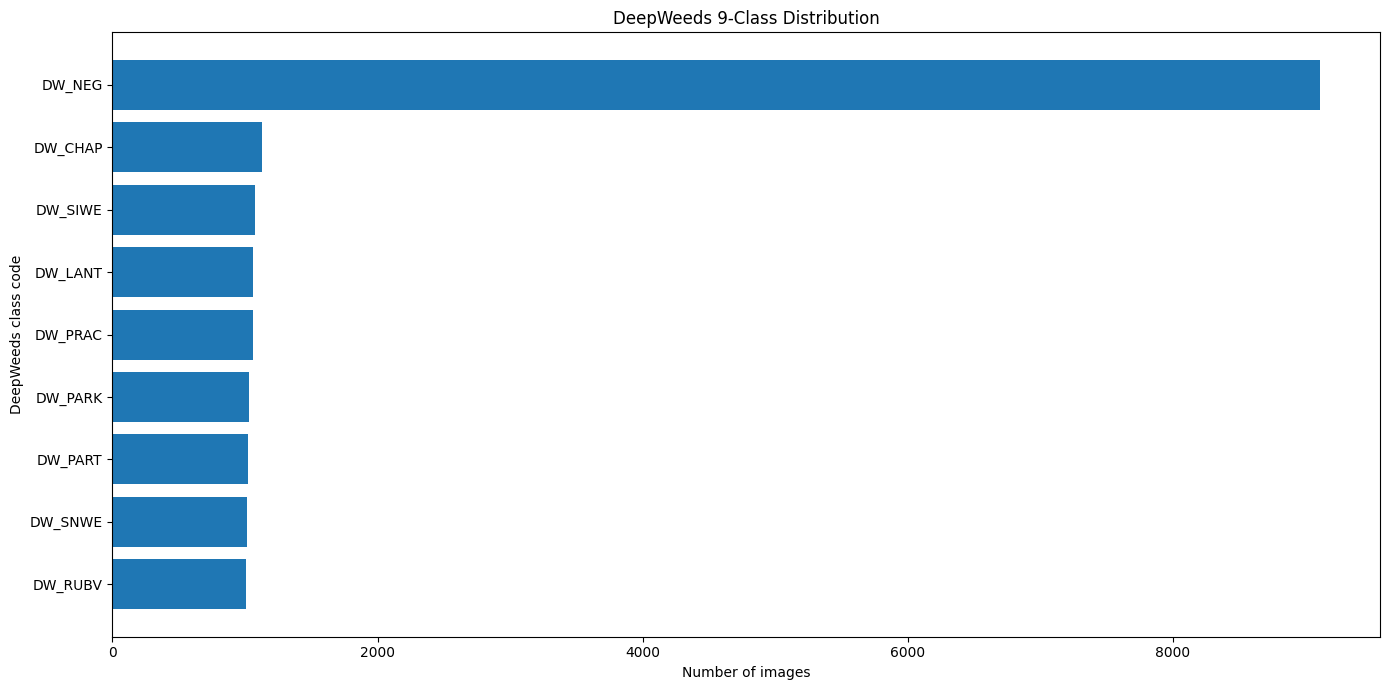


DEEPWEEDS FAST LABEL-RESOLUTION SUMMARY
Mode                  : METADATA-ONLY
Image decoding        : DISABLED
Image integrity scan  : DISABLED
Resolved images       : 17,509
Classes               : 9
Unique groups         : 101
Downstream metadata   : READY


In [7]:
# ---------------------------------------------------------------------------
# Fast DeepWeeds label resolution — metadata only
# ---------------------------------------------------------------------------
#
# PURPOSE
# -------
# Build the complete DeepWeeds metadata table needed by all downstream
# split/training/evaluation cells without opening or decoding every image.
#
# Main optimization:
#   - NO Image.open()
#   - NO Image.verify()
#   - NO im.load()
#   - NO per-image integrity scan
#   - NO ThreadPoolExecutor
#
# The downstream pipeline only needs metadata such as:
#   path
#   eppo
#   class_index
#   class_name
#   trial_id
#   box_id
#   source_image_id
#
# Keep those fields and the lightweight compatibility columns
# (`ok`, `width`, `height`, `status`) without implying that a full image
# integrity scan was performed.
# ---------------------------------------------------------------------------


# ---------------------------------------------------------------------------
# General helpers
# ---------------------------------------------------------------------------

def normalize_name(name: str) -> str:
    return re.sub(
        r"[^a-z0-9]+",
        "_",
        str(name).strip().lower(),
    ).strip("_")


DEEPWEEDS_SPECIES_TO_CODE = {
    "chinee apple": "DW_CHAP",
    "lantana": "DW_LANT",
    "parkinsonia": "DW_PARK",
    "parthenium": "DW_PART",
    "prickly acacia": "DW_PRAC",
    "rubber vine": "DW_RUBV",
    "siam weed": "DW_SIWE",
    "snake weed": "DW_SNWE",
    "negative": "DW_NEG",
    "negatives": "DW_NEG",
    "other": "DW_NEG",
}


EXPECTED_NUMERIC_LABEL = {
    "DW_CHAP": 0,
    "DW_LANT": 1,
    "DW_PARK": 2,
    "DW_PART": 3,
    "DW_PRAC": 4,
    "DW_RUBV": 5,
    "DW_SIWE": 6,
    "DW_SNWE": 7,
    "DW_NEG": 8,
}


CLASS_NAME_BY_CODE = {
    code: info["english"]
    for code, info in SPECIES_INFO.items()
}


def _normalize_species_series(series: pd.Series) -> pd.Series:
    return (
        series
        .astype("string")
        .str.strip()
        .str.lower()
        .str.replace(
            r"\s+",
            " ",
            regex=True,
        )
    )


# ---------------------------------------------------------------------------
# DeepWeeds grouping helper
# ---------------------------------------------------------------------------

def _capture_group_from_filename(
    path: Path,
) -> tuple[str, str]:

    """
    DeepWeeds filenames follow:
        YYYYMMDD-HHMMSS-ID

    Grouping key:
        capture date + instrument ID

    Fallback:
        image stem
    """

    stem = path.stem

    match = re.match(
        r"^(\d{8})-(\d{6})-(\d+)$",
        stem,
    )

    if match:

        date = match.group(1)
        instrument = match.group(3)

        return (
            f"{date}_camera{instrument}",
            date,
        )

    return (
        stem,
        stem,
    )


# ---------------------------------------------------------------------------
# Fast image-path index
# ---------------------------------------------------------------------------
#
# `image_files` was already discovered by the previous dataset-discovery
# section of the notebook.
#
# Normal DeepWeeds filenames are unique, so the common case is
# a single in-memory dictionary lookup:
#
#     filename -> absolute image path
#
# This avoids repeated filesystem checks for every label row.
# ---------------------------------------------------------------------------

BASENAME_TO_PATH: dict[str, str] = {}

DUPLICATE_BASENAMES: set[str] = set()


for _p in image_files:

    _key = _p.name.lower()

    if _key in BASENAME_TO_PATH:

        DUPLICATE_BASENAMES.add(
            _key
        )

    else:

        BASENAME_TO_PATH[_key] = str(
            _p.resolve()
        )


# Remove ambiguous names from the fast dictionary.
#
# This is rare in the official release, but it keeps the fast path conservative.
for _duplicate in DUPLICATE_BASENAMES:
    BASENAME_TO_PATH.pop(
        _duplicate,
        None,
    )


# ---------------------------------------------------------------------------
# Locate labels.csv
# ---------------------------------------------------------------------------

labels_candidates = [
    DATA_ROOT / "labels.csv",
    LOCAL_LABELS_FILE,
]

labels_candidates.extend(
    p
    for p in annotation_files
    if p.name.lower() == "labels.csv"
)


labels_path = next(
    (
        p
        for p in labels_candidates
        if Path(p).is_file()
    ),
    None,
)


if labels_path is None:

    raise RuntimeError(
        "DeepWeeds labels.csv was not found. "
        "The acquisition cell should have downloaded it automatically."
    )


# ---------------------------------------------------------------------------
# Read labels once
# ---------------------------------------------------------------------------

labels_df = pd.read_csv(
    labels_path
)


# ---------------------------------------------------------------------------
# Identify columns
# ---------------------------------------------------------------------------

required_columns = {
    "Filename",
    "Label",
    "Species",
}


if required_columns.issubset(
    labels_df.columns
):

    filename_col = "Filename"
    label_col = "Label"
    species_col = "Species"

else:

    normalized_columns = {
        normalize_name(column): column
        for column in labels_df.columns
    }

    filename_col = normalized_columns.get(
        "filename"
    )

    label_col = normalized_columns.get(
        "label"
    )

    species_col = normalized_columns.get(
        "species"
    )


if not filename_col or not species_col:

    raise RuntimeError(
        f"Could not identify Filename/Species columns in {labels_path}. "
        f"Columns found: {list(labels_df.columns)}"
    )


# ---------------------------------------------------------------------------
# Vectorized species normalization
# ---------------------------------------------------------------------------

species_series = _normalize_species_series(
    labels_df[species_col]
)


# ---------------------------------------------------------------------------
# Vectorized class mapping
# ---------------------------------------------------------------------------

code_series = species_series.map(
    DEEPWEEDS_SPECIES_TO_CODE
)


# ---------------------------------------------------------------------------
# Unknown-species check
# ---------------------------------------------------------------------------

unknown_mask = (
    code_series.isna()
    & species_series.notna()
)


if unknown_mask.any():

    unknown_species = sorted(
        species_series.loc[
            unknown_mask
        ]
        .dropna()
        .unique()
        .tolist()
    )

    raise RuntimeError(
        "Unknown DeepWeeds species labels were encountered: "
        + ", ".join(
            unknown_species
        )
    )


# ---------------------------------------------------------------------------
# Vectorized filename normalization
# ---------------------------------------------------------------------------

filename_series = (
    labels_df[filename_col]
    .astype("string")
    .str.strip()
    .str.replace(
        "\\",
        "/",
        regex=False,
    )
)


basename_series = (
    filename_series
    .str.rsplit(
        "/",
        n=1,
    )
    .str[-1]
)


# ---------------------------------------------------------------------------
# Fast filename -> path resolution
# ---------------------------------------------------------------------------

resolved_path_series = basename_series.map(
    BASENAME_TO_PATH
)


# ---------------------------------------------------------------------------
# Rare fallback for unresolved filenames
# ---------------------------------------------------------------------------
#
# Normally this section is not reached because the basename index resolves
# the official DeepWeeds filenames directly.
#
# Keep the fallback for compatibility with unusual directory layouts
# without adding filesystem checks for all 17,509 rows.
# ---------------------------------------------------------------------------

unresolved_mask = (
    resolved_path_series.isna()
    & filename_series.notna()
)


if unresolved_mask.any():

    fallback_root_candidates = [
        DATA_ROOT,
        DATA_ROOT / "images",
        Path("/content"),
        Path("/content") / "DeepWeeds",
        Path("/content") / "DeepWeeds" / "images",
    ]


    unresolved_indices = (
        labels_df.index[
            unresolved_mask
        ]
    )


    for _idx in unresolved_indices:

        raw_name = filename_series.loc[
            _idx
        ]

        if pd.isna(raw_name):
            continue

        basename = Path(
            str(raw_name)
        ).name


        found = None


        for root_candidate in (
            fallback_root_candidates
        ):

            candidate = (
                root_candidate
                / str(raw_name).lstrip("/")
            )

            if (
                candidate.is_file()
                and candidate.suffix.lower()
                in IMAGE_EXTENSIONS
            ):

                found = str(
                    candidate.resolve()
                )

                break


            candidate = (
                root_candidate
                / basename
            )

            if (
                candidate.is_file()
                and candidate.suffix.lower()
                in IMAGE_EXTENSIONS
            ):

                found = str(
                    candidate.resolve()
                )

                break


        if found is not None:

            resolved_path_series.loc[
                _idx
            ] = found


# ---------------------------------------------------------------------------
# Unresolved image check
# ---------------------------------------------------------------------------

still_unresolved = (
    resolved_path_series.isna()
)


if still_unresolved.any():

    unresolved_images = (
        filename_series.loc[
            still_unresolved
        ]
        .astype(str)
        .head(10)
        .tolist()
    )

    raise RuntimeError(
        f"Could not resolve "
        f"{int(still_unresolved.sum()):,} labeled filenames. "
        f"Examples: {unresolved_images}"
    )


# ---------------------------------------------------------------------------
# Numeric-label consistency check
# ---------------------------------------------------------------------------
#
# This is metadata-only, so it is very cheap.
# No image needs to be opened.
# ---------------------------------------------------------------------------

if label_col:

    numeric_label_series = pd.to_numeric(
        labels_df[label_col],
        errors="coerce",
    )

    expected_label_series = (
        code_series.map(
            EXPECTED_NUMERIC_LABEL
        )
    )

    label_mismatch_mask = (
        numeric_label_series.notna()
        & expected_label_series.notna()
        & (
            numeric_label_series
            != expected_label_series
        )
    )


    if label_mismatch_mask.any():

        first_bad_index = (
            labels_df.index[
                label_mismatch_mask
            ][0]
        )

        raise RuntimeError(
            "DeepWeeds numeric-label mismatch: "
            f"filename={labels_df.loc[first_bad_index, filename_col]!r}, "
            f"numeric Label="
            f"{numeric_label_series.loc[first_bad_index]!r}, "
            f"Species="
            f"{labels_df.loc[first_bad_index, species_col]!r}, "
            f"expected="
            f"{expected_label_series.loc[first_bad_index]!r}."
        )


# ---------------------------------------------------------------------------
# Build metadata directly with vectorized operations
# ---------------------------------------------------------------------------
#
# This replaces the old approach:
#
#     for row in labels_df.itertuples(...):
#         rows.append({...})
#
# with vectorized pandas operations.
#
# ---------------------------------------------------------------------------

metadata = pd.DataFrame(
    {
        "path": resolved_path_series.astype(str),

        "eppo": code_series,

        "source_image_id": (
            resolved_path_series
            .map(
                lambda x: Path(x).stem
            )
        ),
    }
)


# ---------------------------------------------------------------------------
# Remove duplicate labeled paths.
# ---------------------------------------------------------------------------

metadata = (
    metadata
    .drop_duplicates(
        subset=["path"],
        keep="first",
    )
    .reset_index(drop=True)
)


# ---------------------------------------------------------------------------
# Build stable class metadata with vectorized operations.
# ---------------------------------------------------------------------------

metadata["class_index"] = (
    metadata["eppo"]
    .map(CLASS_TO_INDEX)
    .astype(np.int64)
)


metadata["class_name"] = (
    metadata["eppo"]
    .map(CLASS_NAME_BY_CODE)
)


# ---------------------------------------------------------------------------
# Derive capture date and camera grouping with vectorized operations.
# ---------------------------------------------------------------------------

source_ids = (
    metadata["source_image_id"]
    .astype("string")
)


capture_parts = source_ids.str.extract(
    r"^(\d{8})-(\d{6})-(\d+)$",
    expand=True,
)


valid_capture_mask = (
    capture_parts[0].notna()
    & capture_parts[2].notna()
)


# Start with conservative fallback values.
metadata["trial_id"] = (
    source_ids.astype(str)
)

metadata["box_id"] = (
    source_ids.astype(str)
)


# Replace them with date/camera groups when the filename matches the
# official DeepWeeds identifier format.
metadata.loc[
    valid_capture_mask,
    "trial_id",
] = (
    capture_parts.loc[
        valid_capture_mask,
        0,
    ]
    .astype(str)
)


metadata.loc[
    valid_capture_mask,
    "box_id",
] = (
    capture_parts.loc[
        valid_capture_mask,
        0,
    ].astype(str)
    + "_camera"
    + capture_parts.loc[
        valid_capture_mask,
        2,
    ].astype(str)
)


# ---------------------------------------------------------------------------
# Keep the downstream schema expected by the original notebook.
# ---------------------------------------------------------------------------

metadata["plant_id"] = np.nan

metadata["growth_condition"] = np.nan

metadata["xmin"] = np.nan
metadata["ymin"] = np.nan
metadata["xmax"] = np.nan
metadata["ymax"] = np.nan


# ---------------------------------------------------------------------------
# File sizes
# ---------------------------------------------------------------------------
#
# This does not open or decode the images.
#
# os.path.getsize() only reads filesystem metadata.
# ---------------------------------------------------------------------------

metadata["file_size_bytes"] = [
    os.path.getsize(path)
    if os.path.isfile(path)
    else np.nan
    for path in metadata["path"]
]


# ---------------------------------------------------------------------------
# Source strategy
# ---------------------------------------------------------------------------

source_strategy = (
    "deepweeds_official_labels_csv"
)


# ---------------------------------------------------------------------------
# Lightweight compatibility columns
# ---------------------------------------------------------------------------
#
# IMPORTANT:
# These columns do not mean that every file was pixel-validated.
#
# They keep the schema expected by code that may inspect these fields.
# ---------------------------------------------------------------------------

metadata["ok"] = True

metadata["width"] = np.nan

metadata["height"] = np.nan

metadata["status"] = (
    "not_scanned"
)


# ---------------------------------------------------------------------------
# DeepWeeds bounding-box policy
# ---------------------------------------------------------------------------

has_bbox = False

all_square_like = True


# ---------------------------------------------------------------------------
# Final metadata validation
# ---------------------------------------------------------------------------

if metadata.empty:

    raise RuntimeError(
        "No labeled DeepWeeds images were resolved from labels.csv."
    )


if metadata["eppo"].isna().any():

    raise RuntimeError(
        "Some labeled images have no valid DeepWeeds class mapping."
    )


if metadata["path"].isna().any():

    raise RuntimeError(
        "Some labeled images have no resolved filesystem path."
    )


# ---------------------------------------------------------------------------
# Check the complete 9-class set.
# ---------------------------------------------------------------------------

observed_classes = set(
    metadata["eppo"].astype(str)
)


missing_classes = sorted(
    set(SPECIES_CODES)
    - observed_classes
)


if missing_classes:

    raise RuntimeError(
        "The DeepWeeds metadata is missing target classes: "
        f"{missing_classes}"
    )


# ---------------------------------------------------------------------------
# Dataset-level diagnostics
# ---------------------------------------------------------------------------

print(
    "Label-resolution strategy:",
    source_strategy,
)

print(
    "Resolved labeled images:",
    f"{len(metadata):,}",
)

print(
    "Classes present:",
    metadata["eppo"].nunique(),
)

print(
    "Missing classes:",
    missing_classes,
)

print(
    "Labels file:",
    labels_path,
)

print(
    "Image-path index:",
    f"{len(BASENAME_TO_PATH):,} unique filenames",
)

if DUPLICATE_BASENAMES:

    print(
        "Ambiguous duplicate basenames:",
        f"{len(DUPLICATE_BASENAMES):,}",
    )

else:

    print(
        "Ambiguous duplicate basenames: 0"
    )

print(
    "Image integrity scan:",
    "NOT PERFORMED (metadata-only fast path)",
)


# ---------------------------------------------------------------------------
# Class distribution
# ---------------------------------------------------------------------------

class_stats = (
    metadata
    .groupby(
        ["eppo", "class_name"],
        as_index=False,
    )
    .size()
    .rename(
        columns={
            "size": "images"
        }
    )
    .sort_values(
        "images",
        ascending=False,
    )
    .reset_index(drop=True)
)


# ---------------------------------------------------------------------------
# Dataset summary
# ---------------------------------------------------------------------------

summary = pd.DataFrame(
    [
        {
            "Metric": "Number of classes",
            "Value": int(
                metadata["eppo"].nunique()
            ),
        },
        {
            "Metric": "Number of labeled images",
            "Value": int(
                len(metadata)
            ),
        },
        {
            "Metric": "Minimum samples per class",
            "Value": int(
                class_stats["images"].min()
            ),
        },
        {
            "Metric": "Maximum samples per class",
            "Value": int(
                class_stats["images"].max()
            ),
        },
        {
            "Metric": "Mean samples per class",
            "Value": float(
                class_stats["images"].mean()
            ),
        },
        {
            "Metric": "Median samples per class",
            "Value": float(
                class_stats["images"].median()
            ),
        },
    ]
)


# ---------------------------------------------------------------------------
# Image-size statistics
# ---------------------------------------------------------------------------
#
# Width and height are intentionally unavailable because this fast cell does not
# open the image files.
#
# Keep the DataFrame empty instead of fabricating dimensions.
# ---------------------------------------------------------------------------

image_size_stats = pd.DataFrame()


# ---------------------------------------------------------------------------
# Save the required summary tables.
# ---------------------------------------------------------------------------

class_stats.to_csv(
    RESULTS_ROOT
    / "tables"
    / "class_distribution.csv",
    index=False,
)


summary.to_csv(
    RESULTS_ROOT
    / "tables"
    / "dataset_summary.csv",
    index=False,
)


# ---------------------------------------------------------------------------
# Optional metadata artifact
# ---------------------------------------------------------------------------

metadata.to_csv(
    RESULTS_ROOT
    / "tables"
    / "label_resolved_metadata.csv",
    index=False,
)


# ---------------------------------------------------------------------------
# Display the dataset summary.
# ---------------------------------------------------------------------------

print(
    "Dataset summary"
)

display(
    summary
)


print(
    "Top class counts"
)

display(
    class_stats.head(12)
)


# ---------------------------------------------------------------------------
# Class-distribution figure
# ---------------------------------------------------------------------------

fig, ax = plt.subplots(
    figsize=(14, 7)
)


plot_df = (
    class_stats
    .sort_values(
        "images",
        ascending=True,
    )
)


ax.barh(
    plot_df["eppo"],
    plot_df["images"],
)


ax.set_xlabel(
    "Number of images"
)

ax.set_ylabel(
    "DeepWeeds class code"
)

ax.set_title(
    "DeepWeeds 9-Class Distribution"
)


fig.tight_layout()


fig.savefig(
    RESULTS_ROOT
    / "figures"
    / "class_distribution.png",
    dpi=220,
    bbox_inches="tight",
)


plt.show()

plt.close(fig)


# ---------------------------------------------------------------------------
# Final runtime/status report
# ---------------------------------------------------------------------------

print("\n" + "=" * 72)

print(
    "DEEPWEEDS FAST LABEL-RESOLUTION SUMMARY"
)

print("=" * 72)

print(
    "Mode                  : METADATA-ONLY"
)

print(
    "Image decoding        : DISABLED"
)

print(
    "Image integrity scan  : DISABLED"
)

print(
    "Resolved images       : "
    f"{len(metadata):,}"
)

print(
    "Classes               : "
    f"{metadata['eppo'].nunique()}"
)

print(
    "Unique groups         : "
    f"{metadata['box_id'].nunique():,}"
)

print(
    "Downstream metadata   : READY"
)

print("=" * 72)

## Leakage-aware train/validation/test split

DeepWeeds filenames encode capture date/time and instrument ID. The replacement label loader exposes a conservative `box_id`-compatible grouping key based on capture date + instrument ID so the existing grouped split code can stay unchanged. A plain image-level random split is avoided because images from the same capture session can be closely related.


In [8]:
# ---------------------------------------------------------------------------
# Leakage-aware, class-complete 60/20/20 split
# ---------------------------------------------------------------------------
# DeepWeeds does not provide OPPD-style box_id/plant_id metadata. Its official
# filenames use YYYYMMDD-HHMMSS-ID, where the final ID identifies the
# instrument. The original DeepWeeds paper uses a stratified 60/20/20 split.
#
# This cell keeps the requested group-leakage audit, using the most
# defensible grouping available from the DeepWeeds filenames:
#
#   1) derived box_id: capture date + instrument ID
#   2) acquisition timestamp: YYYYMMDD-HHMMSS
#   3) source_image_id as a strict singleton-group fallback
#
# A deterministic seed sweep is used because StratifiedGroupKFold tries to
# preserve class proportions subject to the non-overlapping-group constraint,
# but a particular grouping/seed can still leave a class out of a fold.
#
# Five folds are intentional:
#   fold 0 -> test  (20%)
#   fold 1 -> val   (20%)
#   folds 2-4 -> train (60%)
#
# No random image-level split is used while STRICT_GROUPING=True.

EXPECTED_SPLITS = ("train", "val", "test")
N_SPLITS = 5


def _derive_capture_timestamp(series: pd.Series) -> pd.Series:
    """
    Extract YYYYMMDD-HHMMSS from official DeepWeeds identifiers.

    Expected DeepWeeds filename/stem:
        YYYYMMDD-HHMMSS-ID

    Example:
        20170320-093423-1
        -> 20170320-093423
    """
    text = (
        series
        .astype(str)
        .str.strip()
        .str.replace("\\", "/", regex=False)
    )

    stems = text.map(
        lambda x: Path(x).stem
    )

    return stems.str.extract(
        r"^(\d{8}-\d{6})-\d+$",
        expand=False,
    )


def _candidate_groupings(
    df: pd.DataFrame,
) -> list[tuple[str, pd.Series]]:
    """
    Construct grouping candidates from most meaningful to most conservative.
    """
    candidates: list[tuple[str, pd.Series]] = []

    # -----------------------------------------------------------------------
    # Candidate 1:
    # Strongest grouping available here: the `box_id` field
    # derived from the official filename as capture date + instrument ID.
    # This keeps images from the same acquisition day/camera stream from
    # being deliberately split across partitions.
    # -----------------------------------------------------------------------
    if "box_id" in df.columns and df["box_id"].notna().all():
        box = df["box_id"].astype(str)
        if box.nunique() >= N_SPLITS:
            candidates.append(("box_id", box))

    # -----------------------------------------------------------------------
    # Candidate 2:
    # Exact capture timestamp YYYYMMDD-HHMMSS.
    # -----------------------------------------------------------------------
    if "source_image_id" in df.columns:
        capture_timestamp = _derive_capture_timestamp(df["source_image_id"])
        if capture_timestamp.notna().all():
            candidates.append(
                ("capture_timestamp", capture_timestamp.astype(str))
            )

    # -----------------------------------------------------------------------
    # Candidate 3:
    # Official DeepWeeds unique image identifier.
    # This is a singleton-group fallback and does not provide stronger
    # biological/acquisition grouping.
    # -----------------------------------------------------------------------
    if "source_image_id" in df.columns:
        source_id = df["source_image_id"].astype(str)
        if source_id.notna().all() and source_id.nunique() >= N_SPLITS:
            candidates.append(("source_image_id", source_id))

    # -----------------------------------------------------------------------
    # De-duplicate grouping vectors while keeping candidate order.
    # -----------------------------------------------------------------------
    unique_candidates: list[
        tuple[str, pd.Series]
    ] = []

    seen_signatures: set[
        tuple[str, ...]
    ] = set()

    for name, groups in candidates:

        signature = tuple(
            groups.to_numpy(
                dtype=str
            )
        )

        if signature not in seen_signatures:

            unique_candidates.append(
                (
                    name,
                    groups,
                )
            )

            seen_signatures.add(
                signature
            )

    return unique_candidates


def _groups_have_enough_class_support(
    y: np.ndarray,
    groups: np.ndarray,
    n_splits: int,
) -> bool:
    """
    Check the necessary condition for every class to have at least one
    group in every fold.
    """
    temp = pd.DataFrame(
        {
            "class_index": y,
            "group_id": groups,
        }
    )

    support = (
        temp
        .groupby("class_index")["group_id"]
        .nunique()
    )

    expected_class_indices = set(
        range(len(SPECIES_CODES))
    )

    if set(support.index) != expected_class_indices:
        return False

    return bool(
        (support >= n_splits).all()
    )


def _try_stratified_group_folds(
    y: np.ndarray,
    groups: np.ndarray,
    seed: int,
    n_splits: int,
) -> Optional[np.ndarray]:
    """
    Build a StratifiedGroupKFold assignment and accept it only if all target
    classes appear in every fold.
    """
    if not _groups_have_enough_class_support(
        y,
        groups,
        n_splits,
    ):
        return None

    X = np.zeros(
        (
            len(y),
            1,
        ),
        dtype=np.float32,
    )

    splitter = StratifiedGroupKFold(
        n_splits=n_splits,
        shuffle=True,
        random_state=seed,
    )

    folds = np.full(
        len(y),
        -1,
        dtype=np.int16,
    )

    try:

        for fold_id, (_, val_idx) in enumerate(
            splitter.split(
                X,
                y,
                groups,
            )
        ):

            folds[val_idx] = fold_id

    except ValueError:
        return None

    if (folds < 0).any():
        return None

    # Every target class must appear in every fold.
    expected_class_indices = set(
        range(len(SPECIES_CODES))
    )

    for fold_id in range(n_splits):

        observed_class_indices = set(
            np.asarray(y)[
                folds == fold_id
            ]
        )

        if (
            observed_class_indices
            != expected_class_indices
        ):
            return None

    return folds


def make_grouped_split(
    df: pd.DataFrame,
    seed: int,
) -> tuple[pd.DataFrame, str, int]:

    out = df.copy()

    if out.empty:
        raise RuntimeError(
            "Cannot create a split from an empty metadata table."
        )

    if "class_index" not in out.columns:
        raise RuntimeError(
            "metadata must contain 'class_index' before splitting."
        )

    if "eppo" not in out.columns:
        raise RuntimeError(
            "metadata must contain 'eppo' before splitting."
        )

    expected_classes = set(
        SPECIES_CODES
    )

    observed_classes = set(
        out["eppo"]
        .dropna()
        .astype(str)
    )

    missing_classes = sorted(
        expected_classes
        - observed_classes
    )

    if missing_classes:
        raise RuntimeError(
            "The metadata is missing target classes before splitting: "
            f"{missing_classes}"
        )

    y = (
        out["class_index"]
        .to_numpy()
    )

    candidate_groupings = (
        _candidate_groupings(out)
    )

    if not candidate_groupings:

        if STRICT_GROUPING:
            raise RuntimeError(
                "No valid DeepWeeds grouping key is available. "
                "DeepWeeds does not provide OPPD-style box_id/plant_id "
                "metadata."
            )

        candidate_groupings = [
            (
                "path",
                pd.Series(
                    out.index.astype(str),
                    index=out.index,
                ),
            )
        ]

    # -----------------------------------------------------------------------
    # Deterministic seed sweep.
    #
    # Trying several seeds is still reproducible because the sequence is
    # completely determined by the user-specified SEED.
    # -----------------------------------------------------------------------
    trial_seeds = [
        int(seed + offset)
        for offset in range(50)
    ]

    selected_name: Optional[str] = None
    selected_groups: Optional[pd.Series] = None
    selected_folds: Optional[np.ndarray] = None
    selected_seed: Optional[int] = None

    # -----------------------------------------------------------------------
    # Try groupings from the strongest semantic grouping to the safest conservative
    # fallback.
    # -----------------------------------------------------------------------
    for group_name, group_series in candidate_groupings:

        groups = (
            group_series
            .astype(str)
            .to_numpy()
        )

        class_group_support = (
            pd.DataFrame(
                {
                    "class": out["eppo"].astype(str),
                    "group": groups,
                }
            )
            .groupby("class")["group"]
            .nunique()
            .reindex(
                SPECIES_CODES
            )
        )

        # A class needs at least N_SPLITS different groups to appear in
        # every fold without splitting a group.
        if (
            class_group_support.isna().any()
            or (
                class_group_support
                < N_SPLITS
            ).any()
        ):
            continue

        for trial_seed in trial_seeds:

            folds = _try_stratified_group_folds(
                y=y,
                groups=groups,
                seed=trial_seed,
                n_splits=N_SPLITS,
            )

            if folds is None:
                continue

            selected_name = group_name
            selected_groups = (
                group_series.astype(str)
            )
            selected_folds = folds
            selected_seed = trial_seed

            break

        if selected_folds is not None:
            break

    # -----------------------------------------------------------------------
    # No feasible grouping found.
    # -----------------------------------------------------------------------
    if (
        selected_folds is None
        or selected_groups is None
        or selected_name is None
        or selected_seed is None
    ):

        diagnostics = []

        for group_name, group_series in candidate_groupings:

            groups = (
                group_series
                .astype(str)
            )

            support = (
                pd.DataFrame(
                    {
                        "class": out["eppo"].astype(str),
                        "group": groups,
                    }
                )
                .groupby("class")["group"]
                .nunique()
                .reindex(
                    SPECIES_CODES
                )
            )

            diagnostics.append(
                f"{group_name}: "
                f"min groups/class="
                f"{int(support.min())}"
            )

        raise RuntimeError(
            "No class-complete, group-disjoint 5-fold split "
            "could be found. This indicates that the requested "
            "grouping constraint is incompatible with the available "
            "DeepWeeds grouping metadata.\n"
            "Diagnostics: "
            + " | ".join(diagnostics)
        )

    # -----------------------------------------------------------------------
    # Save the selected grouping.
    # -----------------------------------------------------------------------
    out["group_id"] = (
        selected_groups
        .to_numpy()
    )

    # -----------------------------------------------------------------------
    # Five-fold-derived geometry used by this notebook:
    #
    #   Fold 0 -> Test
    #   Fold 1 -> Validation
    #   Folds 2,3,4 -> Training
    #
    # The nominal partition is therefore 60/20/20. This is a deterministic
    # leakage-aware reconstruction, not a claim that the selected fold
    # assignment matches the repository's published CSV assignments.
    # -----------------------------------------------------------------------
    out["split"] = np.where(
        selected_folds == 0,
        "test",
        np.where(
            selected_folds == 1,
            "val",
            "train",
        ),
    )

    # -----------------------------------------------------------------------
    # Defensive class-completeness checks.
    # -----------------------------------------------------------------------
    for split_name in EXPECTED_SPLITS:

        split_classes = set(
            out.loc[
                out["split"] == split_name,
                "eppo",
            ]
            .astype(str)
        )

        if (
            split_classes
            != expected_classes
        ):

            missing = sorted(
                expected_classes
                - split_classes
            )

            raise RuntimeError(
                f"Internal split construction failed for "
                f"{split_name}. Missing classes: {missing}"
            )

    # -----------------------------------------------------------------------
    # Defensive group-leakage checks.
    # -----------------------------------------------------------------------
    for a, b in (
        ("train", "val"),
        ("train", "test"),
        ("val", "test"),
    ):

        A = set(
            out.loc[
                out["split"] == a,
                "group_id",
            ]
        )

        B = set(
            out.loc[
                out["split"] == b,
                "group_id",
            ]
        )

        overlap = A.intersection(B)

        if overlap:

            raise AssertionError(
                f"Group leakage detected between "
                f"{a} and {b}: {len(overlap)} groups."
            )

    # -----------------------------------------------------------------------
    # Diagnostic output.
    # -----------------------------------------------------------------------
    print(
        "Grouping strategy selected:",
        selected_name,
    )

    print(
        "Split seed selected:",
        selected_seed,
    )

    if selected_name == "source_image_id":

        print(
            "Note: DeepWeeds provides unique image identifiers "
            "rather than plant/box IDs. source_image_id is therefore "
            "a singleton-group leakage guard, not a biological "
            "plant/box grouping variable."
        )

    return out, selected_name, selected_seed


# ---------------------------------------------------------------------------
# Create the deterministic split.
# ---------------------------------------------------------------------------
metadata, selected_name, selected_seed = make_grouped_split(
    metadata,
    SEED,
)


# ---------------------------------------------------------------------------
# Summary tables.
# ---------------------------------------------------------------------------
split_counts = (
    metadata["split"]
    .value_counts()
    .rename_axis("split")
    .reindex(
        EXPECTED_SPLITS
    )
    .reset_index(
        name="images"
    )
)

split_class = pd.crosstab(
    metadata["eppo"],
    metadata["split"],
).reindex(
    index=SPECIES_CODES,
    columns=EXPECTED_SPLITS,
    fill_value=0,
)


# ---------------------------------------------------------------------------
# Every target class must appear in all three partitions.
# ---------------------------------------------------------------------------
for split_name in EXPECTED_SPLITS:

    missing = sorted(
        set(SPECIES_CODES)
        - set(
            metadata.loc[
                metadata["split"] == split_name,
                "eppo",
            ]
        )
    )

    if missing:

        raise RuntimeError(
            f"Missing classes in {split_name} split: {missing}"
        )


# ---------------------------------------------------------------------------
# Group leakage audit.
# ---------------------------------------------------------------------------
group_overlap = {}

for a, b in (
    ("train", "val"),
    ("train", "test"),
    ("val", "test"),
):

    A = set(
        metadata.loc[
            metadata["split"] == a,
            "group_id",
        ]
    )

    B = set(
        metadata.loc[
            metadata["split"] == b,
            "group_id",
        ]
    )

    group_overlap[
        f"{a}∩{b}"
    ] = len(
        A & B
    )

if any(
    group_overlap.values()
):
    raise AssertionError(
        f"Group leakage detected: "
        f"{group_overlap}"
    )


# ---------------------------------------------------------------------------
# Save split artifacts.
# ---------------------------------------------------------------------------
metadata.to_csv(
    RESULTS_ROOT
    / "tables"
    / "split_metadata.csv",
    index=False,
)

split_counts.to_csv(
    RESULTS_ROOT
    / "tables"
    / "split_summary.csv",
    index=False,
)

split_class.to_csv(
    RESULTS_ROOT
    / "tables"
    / "split_class_counts.csv"
)


# ---------------------------------------------------------------------------
# Save the explicit split configuration for reproducibility/auditability.
# ---------------------------------------------------------------------------
split_config = {
    "n_splits": int(N_SPLITS),
    "assignment_geometry": {
        "test_fold": 0,
        "validation_fold": 1,
        "training_folds": [2, 3, 4],
    },
    "grouping_strategy_selected": selected_name,
    "split_seed_selected": int(selected_seed),
    "strict_grouping": bool(STRICT_GROUPING),
    "candidate_priority": [
        "box_id (capture date + instrument ID)",
        "capture_timestamp",
        "source_image_id",
    ],
    "note": (
        "Leakage-aware reconstruction; not claimed to reproduce the "
        "repository's exact published subset CSV assignment."
    ),
}
(RESULTS_ROOT / "configs" / "split_config.json").write_text(
    json.dumps(split_config, indent=2),
    encoding="utf-8",
)

# ---------------------------------------------------------------------------
# Display diagnostics.
# ---------------------------------------------------------------------------
print(
    "Number of groups:",
    metadata["group_id"].nunique(),
)

print(
    "Split summary:"
)

display(
    split_counts
)

print(
    "Class-by-split counts:"
)

display(
    split_class
)

print(
    "Group-overlap audit:",
    group_overlap,
)


# ---------------------------------------------------------------------------
# Save the complete deterministic split and SHA-256 checksum.
# ---------------------------------------------------------------------------
split_path = (
    RESULTS_ROOT
    / "configs"
    / "split_metadata.csv"
)

metadata.to_csv(
    split_path,
    index=False,
)

sha = hashlib.sha256(
    split_path.read_bytes()
).hexdigest()

(
    RESULTS_ROOT
    / "configs"
    / "split_metadata.sha256"
).write_text(
    sha + "\n",
    encoding="utf-8",
)

print(
    "Split checksum:",
    sha,
)

Grouping strategy selected: capture_timestamp
Split seed selected: 42
Number of groups: 17204
Split summary:


,split,images
0,train,10495
1,val,3509
2,test,3505


Class-by-split counts:


split,train,val,test
eppo,,,
DW_CHAP,670,229,226
DW_LANT,640,212,212
DW_PARK,619,208,204
DW_PART,610,199,213
DW_PRAC,637,215,210
DW_RUBV,609,205,195
DW_SIWE,640,216,218
DW_SNWE,614,207,195
DW_NEG,5456,1818,1832


Group-overlap audit: {'train∩val': 0, 'train∩test': 0, 'val∩test': 0}
Split checksum: b5261f61c53c8f598169506be60c027579149170f453253cbbbe3289a64d3998


## Data transforms

All models use the same 224×224 input size, ImageNet normalization, and deterministic validation/test preprocessing. Training augmentation is intentionally mild: resize/crop, horizontal flip, small rotation, and limited color/affine variation. These augmentations are used only for the training dataset.


In [9]:
IMAGENET_MEAN = (0.485, 0.456, 0.406)
IMAGENET_STD = (0.229, 0.224, 0.225)

# Use the normalization expected by each pretrained model.
# The timm ViT-Tiny checkpoint used below specifies mean/std=(0.5, 0.5, 0.5),
# while the torchvision CNNs use ImageNet normalization.
MODEL_NORMALIZATION = {
    "efficientnet_b0": (IMAGENET_MEAN, IMAGENET_STD),
    "mobilenet_v3_large": (IMAGENET_MEAN, IMAGENET_STD),
    "vit_tiny": ((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)),
}

train_transform = transforms.Compose([
    transforms.RandomResizedCrop(IMAGE_SIZE, scale=(0.75, 1.0), ratio=(0.9, 1.1)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ColorJitter(brightness=0.15, contrast=0.15, saturation=0.10, hue=0.02),
    # Combine rotation, translation, and mild scaling into one affine operation.
    transforms.RandomAffine(
        degrees=10,
        translate=(0.03, 0.03),
        scale=(0.95, 1.05),
    ),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

# Use standard resize-then-center-crop geometry for ImageNet-pretrained models
# instead of stretching every image anisotropically to 224x224.
EVAL_RESIZE = int(round(IMAGE_SIZE / 0.875))
eval_transform = transforms.Compose([
    transforms.Resize(EVAL_RESIZE, interpolation=InterpolationMode.BILINEAR),
    transforms.CenterCrop(IMAGE_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])


def build_model_transforms(model_name: str):
    if model_name not in MODEL_NORMALIZATION:
        raise ValueError(f"Unknown model transform profile: {model_name}")

    mean, std = MODEL_NORMALIZATION[model_name]
    interpolation = (
        InterpolationMode.BICUBIC
        if model_name == "vit_tiny"
        else InterpolationMode.BILINEAR
    )

    train_tf = transforms.Compose([
        transforms.RandomResizedCrop(
            IMAGE_SIZE,
            scale=(0.75, 1.0),
            ratio=(0.9, 1.1),
            interpolation=interpolation,
        ),
        transforms.RandomHorizontalFlip(p=0.5),
        transforms.ColorJitter(
            brightness=0.15,
            contrast=0.15,
            saturation=0.10,
            hue=0.02,
        ),
        transforms.RandomAffine(
            degrees=10,
            translate=(0.03, 0.03),
            scale=(0.95, 1.05),
            interpolation=interpolation,
        ),
        transforms.ToTensor(),
        transforms.Normalize(mean, std),
    ])

    eval_tf = transforms.Compose([
        transforms.Resize(EVAL_RESIZE, interpolation=interpolation),
        transforms.CenterCrop(IMAGE_SIZE),
        transforms.ToTensor(),
        transforms.Normalize(mean, std),
    ])
    return train_tf, eval_tf


class OPPDPlantDataset(Dataset):
    def __init__(self, frame: pd.DataFrame, transform: transforms.Compose):
        frame = frame.reset_index(drop=True)
        # Avoid a pandas .iloc/.Series lookup for every sample. These compact
        # NumPy arrays are much cheaper inside DataLoader workers.
        self.paths = frame["path"].to_numpy(dtype=str, copy=True)
        self.labels = frame["class_index"].to_numpy(dtype=np.int64, copy=True)
        self.transform = transform

    def __len__(self) -> int:
        return len(self.paths)

    def __getitem__(self, index: int):
        path = self.paths[index]
        with Image.open(path) as im:
            image = im.convert("RGB")
        image = self.transform(image)
        label = int(self.labels[index])
        return image, label, path


def stratified_cap(frame: pd.DataFrame, max_samples: int | None, seed: int) -> pd.DataFrame:
    if max_samples is None or len(frame) <= max_samples:
        return frame.reset_index(drop=True).copy()
    # Keep the same class proportions for all architectures so the comparison stays fair.
    rng = np.random.default_rng(seed)
    groups = []
    class_counts = frame["class_index"].value_counts().sort_index()
    raw = class_counts / class_counts.sum() * max_samples
    quotas = np.floor(raw).astype(int)
    quotas = quotas.clip(lower=1)
    excess = int(quotas.sum() - max_samples)
    while excess > 0:
        candidates = quotas[quotas > 1].sort_values(ascending=False).index
        if len(candidates) == 0:
            break
        for cls in candidates:
            if excess <= 0:
                break
            quotas.loc[cls] -= 1
            excess -= 1
    for cls, n in quotas.items():
        part = frame[frame["class_index"] == cls]
        idx = rng.choice(len(part), size=min(int(n), len(part)), replace=False)
        groups.append(part.iloc[idx])
    out = pd.concat(groups, ignore_index=True)
    return out.sample(frac=1.0, random_state=seed).reset_index(drop=True)


train_df = stratified_cap(metadata[metadata["split"] == "train"], FINAL_MAX_TRAIN_SAMPLES, SEED)
val_df = metadata[metadata["split"] == "val"].reset_index(drop=True)
test_df = metadata[metadata["split"] == "test"].reset_index(drop=True)

pilot_train_df = stratified_cap(train_df, PILOT_MAX_TRAIN_SAMPLES, SEED)

train_ds = OPPDPlantDataset(train_df, train_transform)
val_ds = OPPDPlantDataset(val_df, eval_transform)
test_ds = OPPDPlantDataset(test_df, eval_transform)

def seed_worker(worker_id: int) -> None:
    # DataLoader derives a unique PyTorch seed per worker from the generator;
    # mirror it into the NumPy/Python RNGs used by any future worker-side code.
    worker_seed = torch.initial_seed() % (2**32)
    np.random.seed(worker_seed)
    random.seed(worker_seed)


loader_kwargs = {
    "num_workers": NUM_WORKERS,
    "pin_memory": PIN_MEMORY,
    "worker_init_fn": seed_worker,
}
if NUM_WORKERS > 0:
    loader_kwargs["persistent_workers"] = True
    loader_kwargs["prefetch_factor"] = PREFETCH_FACTOR


def shutdown_loader_workers(loader: Optional[DataLoader]) -> None:
    """
    Explicitly stop persistent DataLoader workers when a loader reaches the end
    of its lifecycle. This preserves the multi-epoch speed benefit without
    retaining worker processes across separate model experiments.
    """
    if loader is None:
        return

    iterator = getattr(loader, "_iterator", None)
    shutdown = getattr(iterator, "_shutdown_workers", None)
    if callable(shutdown):
        shutdown()
    if hasattr(loader, "_iterator"):
        loader._iterator = None


def make_loader(ds: Dataset, shuffle: bool) -> DataLoader:
    generator = torch.Generator()
    generator.manual_seed(SEED)
    return DataLoader(
        ds,
        batch_size=BATCH_SIZE,
        shuffle=shuffle,
        drop_last=False,
        generator=generator,
        **loader_kwargs,
    )


train_loader = make_loader(train_ds, shuffle=True)
val_loader = make_loader(val_ds, shuffle=False)
test_loader = make_loader(test_ds, shuffle=False)

print(f"Train samples: {len(train_ds):,}")
print(f"Validation samples: {len(val_ds):,}")
print(f"Test samples: {len(test_ds):,}")

def compute_balanced_weights(frame: pd.DataFrame) -> torch.Tensor:
    counts = frame["class_index"].value_counts().reindex(range(len(SPECIES_CODES)), fill_value=0)
    n = counts.sum()
    c = len(counts)
    if (counts == 0).any():
        missing = counts[counts == 0].index.tolist()
        raise ValueError(f"Cannot compute class weights; classes absent from training data: {missing}")
    weights = n / (c * counts.to_numpy(dtype=np.float64))
    weights = weights / weights.mean()
    return torch.tensor(weights, dtype=torch.float32, device=DEVICE)


CLASS_WEIGHTS = compute_balanced_weights(train_df)
print("Class-weight range:", float(CLASS_WEIGHTS.min()), float(CLASS_WEIGHTS.max()))

Train samples: 10,495
Validation samples: 3,509
Test samples: 3,505
Class-weight range: 0.12791021168231964 1.145941138267517


## Model definitions

Three models are compared under the same data protocol:

- **EfficientNet-B0:** efficient CNN baseline with ImageNet pretraining.
- **MobileNetV3-Large:** lightweight CNN with ImageNet pretraining.
- **ViT-Tiny:** practical pretrained transformer model from `timm` using 224×224 input.

All classification heads are replaced with exactly **9 output logits**, matching the nine DeepWeeds classes. Each pretrained architecture uses its documented input normalization profile.


In [10]:
def build_model(name: str, num_classes: int) -> nn.Module:
    if name == "efficientnet_b0":
        model = models.efficientnet_b0(weights=EfficientNet_B0_Weights.DEFAULT)
        in_features = model.classifier[-1].in_features
        model.classifier[-1] = nn.Linear(in_features, num_classes)
        return model

    if name == "mobilenet_v3_large":
        model = models.mobilenet_v3_large(weights=MobileNet_V3_Large_Weights.DEFAULT)
        in_features = model.classifier[-1].in_features
        model.classifier[-1] = nn.Linear(in_features, num_classes)
        return model

    if name == "vit_tiny":
        # The timm model name is small enough for Colab while still
        # giving us a genuine transformer comparison.
        return timm.create_model(
            "vit_tiny_patch16_224",
            pretrained=True,
            num_classes=num_classes,
            img_size=IMAGE_SIZE,
        )

    raise ValueError(f"Unknown model: {name}")


def count_parameters(model: nn.Module) -> tuple[int, int]:
    total = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    return total, trainable


def freeze_for_stage(model: nn.Module, model_name: str, stage: str) -> None:
    if stage not in {"head", "finetune"}:
        raise ValueError(stage)
    for p in model.parameters():
        p.requires_grad = False

    if model_name == "efficientnet_b0":
        for p in model.classifier.parameters():
            p.requires_grad = True
        if stage == "finetune":
            for block in model.features[-2:]:
                for p in block.parameters():
                    p.requires_grad = True

    elif model_name == "mobilenet_v3_large":
        for p in model.classifier.parameters():
            p.requires_grad = True
        if stage == "finetune":
            for block in model.features[-3:]:
                for p in block.parameters():
                    p.requires_grad = True

    elif model_name == "vit_tiny":
        for p in model.head.parameters():
            p.requires_grad = True
        if hasattr(model, "fc_norm") and model.fc_norm is not None:
            for p in model.fc_norm.parameters():
                p.requires_grad = True
        if stage == "finetune":
            n = len(model.blocks)
            start = max(0, n - 2)
            for block in model.blocks[start:]:
                for p in block.parameters():
                    p.requires_grad = True
            if hasattr(model, "norm"):
                for p in model.norm.parameters():
                    p.requires_grad = True
    else:
        raise ValueError(model_name)


def build_optimizer(
    model: nn.Module,
    model_name: str,
    stage: str,
    backbone_lr: float,
    head_lr: float,
    weight_decay: float,
) -> torch.optim.Optimizer:
    if stage not in {"head", "finetune"}:
        raise ValueError(stage)

    head_prefixes = {
        "efficientnet_b0": ("classifier.",),
        "mobilenet_v3_large": ("classifier.",),
        "vit_tiny": ("head.",),
    }[model_name]

    trainable = [
        (name, param)
        for name, param in model.named_parameters()
        if param.requires_grad
    ]
    if not trainable:
        raise RuntimeError(f"No trainable parameters found for {model_name}/{stage}.")

    if stage == "head":
        params = [param for _, param in trainable]
        return torch.optim.AdamW(
            params,
            lr=head_lr,
            weight_decay=weight_decay,
        )

    head_params = [
        param
        for name, param in trainable
        if any(name.startswith(prefix) for prefix in head_prefixes)
    ]
    backbone_params = [
        param
        for name, param in trainable
        if not any(name.startswith(prefix) for prefix in head_prefixes)
    ]

    groups = []
    if backbone_params:
        groups.append({
            "params": backbone_params,
            "lr": backbone_lr,
            "weight_decay": weight_decay,
        })
    if head_params:
        groups.append({
            "params": head_params,
            "lr": head_lr,
            "weight_decay": weight_decay,
        })

    if not groups:
        raise RuntimeError(f"Could not form optimizer parameter groups for {model_name}/{stage}.")

    return torch.optim.AdamW(groups)


def topk_accuracy(logits: torch.Tensor, labels: torch.Tensor, k: int = 1) -> float:
    k = min(k, logits.size(1))
    correct = logits.topk(k, dim=1).indices.eq(labels.view(-1, 1)).any(dim=1)
    return float(correct.float().mean().item())


def _batch_accuracy_counts(
    logits: torch.Tensor,
    labels: torch.Tensor,
    max_k: int = 5,
) -> tuple[torch.Tensor, torch.Tensor]:
    max_k = min(max_k, logits.size(1))
    pred = logits.topk(max_k, dim=1).indices
    correct = pred.eq(labels.view(-1, 1))
    top1 = correct[:, :1].sum(dtype=torch.int64)
    topk = correct.any(dim=1).sum(dtype=torch.int64)
    return top1, topk


def _set_train_mode(model: nn.Module, train: bool) -> None:
    model.train(train)
    if not train:
        return
    # Frozen convolutional backbones should not keep updating BatchNorm
    # running statistics during the classifier-only stage. This avoids
    # changing pretrained feature statistics without gradient updates.
    bn_types = (
        nn.BatchNorm1d,
        nn.BatchNorm2d,
        nn.BatchNorm3d,
        nn.SyncBatchNorm,
    )
    for module in model.modules():
        if isinstance(module, bn_types):
            trainable_params = any(p.requires_grad for p in module.parameters(recurse=False))
            if not trainable_params:
                module.eval()


def run_epoch(
    model: nn.Module,
    loader: DataLoader,
    criterion: nn.Module,
    optimizer: Optional[torch.optim.Optimizer],
    scaler: Optional[torch.amp.GradScaler],
    train: bool,
    description: Optional[str] = None,
) -> dict[str, float]:
    _set_train_mode(model, train)
    running_loss = torch.zeros((), device=DEVICE, dtype=torch.float32)
    top1_correct = torch.zeros((), device=DEVICE, dtype=torch.int64)
    top5_correct = torch.zeros((), device=DEVICE, dtype=torch.int64)
    total = 0
    start = time.perf_counter()

    progress = tqdm(
        loader,
        total=len(loader),
        desc=description or ("train" if train else "eval"),
        unit="batch",
        leave=False,
        dynamic_ncols=True,
    )

    grad_context = torch.enable_grad() if train else torch.inference_mode()
    with grad_context:
        for images, labels, _ in progress:
            images = images.to(DEVICE, non_blocking=PIN_MEMORY)
            labels = labels.to(DEVICE, non_blocking=PIN_MEMORY)

            if train:
                optimizer.zero_grad(set_to_none=True)

            with torch.autocast(
                device_type=DEVICE.type,
                dtype=AMP_DTYPE,
                enabled=AMP_ENABLED,
            ):
                logits = model(images)
                loss = criterion(logits, labels)

            if train:
                if USE_GRAD_SCALER:
                    scaler.scale(loss).backward()
                    scaler.step(optimizer)
                    scaler.update()
                else:
                    loss.backward()
                    optimizer.step()

            batch_n = labels.size(0)
            running_loss += loss.detach().float() * batch_n
            b1, b5 = _batch_accuracy_counts(logits.detach(), labels, max_k=5)
            top1_correct += b1
            top5_correct += b5
            total += batch_n

            # Keep the progress bar informative without synchronizing a GPU
            # scalar to CPU on every batch.
            if progress.n % 16 == 0:
                progress.set_postfix(
                    processed=f"{total:,} img",
                    refresh=False,
                )

    elapsed = time.perf_counter() - start
    loss_value = float((running_loss / max(total, 1)).item())
    top1_value = float((top1_correct.float() / max(total, 1)).item())
    top5_value = float((top5_correct.float() / max(total, 1)).item())

    return {
        "loss": loss_value,
        "top1": top1_value,
        "top5": top5_value,
        "seconds": elapsed,
        "samples_per_second": float(total / max(elapsed, 1e-9)),
    }


def evaluate_predictions(
    model: nn.Module,
    loader: DataLoader,
) -> tuple[np.ndarray, np.ndarray, np.ndarray, list[str]]:
    model.eval()
    all_true, all_pred, all_prob, all_paths = [], [], [], []

    with torch.inference_mode():
        progress = tqdm(
            loader,
            total=len(loader),
            desc="test inference",
            unit="batch",
            leave=False,
            dynamic_ncols=True,
        )
        for images, labels, paths in progress:
            images = images.to(DEVICE, non_blocking=PIN_MEMORY)
            with torch.autocast(
                device_type=DEVICE.type,
                dtype=AMP_DTYPE,
                enabled=AMP_ENABLED,
            ):
                logits = model(images)

            probs = torch.softmax(logits.float(), dim=1)
            pred = probs.argmax(dim=1)

            all_true.append(labels.numpy())
            all_pred.append(pred.cpu().numpy())
            all_prob.append(probs.cpu().numpy())
            all_paths.extend(paths)

    return (
        np.concatenate(all_true),
        np.concatenate(all_pred),
        np.concatenate(all_prob),
        all_paths,
    )


def macro_metrics(y_true: np.ndarray, y_pred: np.ndarray) -> dict[str, float]:
    precision, recall, f1, _ = precision_recall_fscore_support(
        y_true,
        y_pred,
        labels=np.arange(len(SPECIES_CODES)),
        average=None,
        zero_division=0,
    )
    macro_p = float(np.mean(precision))
    macro_r = float(np.mean(recall))
    macro_f1 = float(np.mean(f1))
    weighted_f1 = float(
        precision_recall_fscore_support(
            y_true,
            y_pred,
            labels=np.arange(len(SPECIES_CODES)),
            average="weighted",
            zero_division=0,
        )[2]
    )
    return {
        "accuracy": float(accuracy_score(y_true, y_pred)),
        "macro_precision": macro_p,
        "macro_recall": macro_r,
        "macro_f1": macro_f1,
        "weighted_f1": weighted_f1,
    }


def save_checkpoint(path: Path, model: nn.Module, optimizer: torch.optim.Optimizer, epoch: int, best_val: float, config: dict) -> None:
    torch.save({
        "model_state": model.state_dict(),
        "optimizer_state": optimizer.state_dict(),
        "epoch": epoch,
        "best_val": best_val,
        "config": config,
        "class_to_index": CLASS_TO_INDEX,
    }, path)


def load_best_checkpoint(model: nn.Module, path: Path) -> dict[str, Any]:
    try:
        payload = torch.load(path, map_location=DEVICE, weights_only=False)
    except TypeError:
        payload = torch.load(path, map_location=DEVICE)
    model.load_state_dict(payload["model_state"])
    return payload


def train_experiment(
    model_name: str,
    config: dict,
    train_frame: pd.DataFrame,
    val_frame_local: pd.DataFrame,
    epochs_head: int,
    epochs_finetune: int,
    tag: str,
) -> tuple[nn.Module, dict[str, Any]]:
    seed_everything(SEED)
    model = build_model(model_name, len(SPECIES_CODES)).to(DEVICE)
    criterion = nn.CrossEntropyLoss(weight=CLASS_WEIGHTS)

    if USE_GRAD_SCALER:
        try:
            scaler = torch.amp.GradScaler("cuda", enabled=True)
        except (AttributeError, TypeError):
            scaler = torch.cuda.amp.GradScaler(enabled=True)
    else:
        scaler = None

    checkpoint_path = RESULTS_ROOT / "checkpoints" / f"{tag}_best.pt"
    history_rows = []
    best_val = -np.inf
    best_epoch = -1
    total_start = time.perf_counter()
    stopped_early = False
    patience_counter = 0

    # Create one train loader per experiment. Persistent workers stay alive
    # across the head/fine-tuning epochs, then are shut down explicitly below.
    model_train_transform, model_eval_transform = build_model_transforms(model_name)
    train_dataset = OPPDPlantDataset(train_frame, model_train_transform)
    val_dataset = OPPDPlantDataset(val_frame_local, model_eval_transform)
    local_train_loader = make_loader(train_dataset, shuffle=True)
    local_val_loader = make_loader(val_dataset, shuffle=False)

    stage_specs = [
        ("head", epochs_head, config["head_lr"]),
        ("finetune", epochs_finetune, config["finetune_lr"]),
    ]

    try:
        for stage_name, epochs, lr in stage_specs:
            if epochs <= 0:
                continue

            freeze_for_stage(model, model_name, stage_name)
            optimizer = build_optimizer(
                model=model,
                model_name=model_name,
                stage=stage_name,
                backbone_lr=lr,
                head_lr=config["head_lr"],
                weight_decay=config["weight_decay"],
            )
            scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
                optimizer,
                T_max=max(1, epochs),
            )

            for _local_epoch in range(epochs):
                epoch = len(history_rows) + 1
                current_lr = float(optimizer.param_groups[0]["lr"])

                if DEVICE.type == "cuda":
                    torch.cuda.reset_peak_memory_stats()

                train_metrics = run_epoch(
                    model,
                    local_train_loader,
                    criterion,
                    optimizer,
                    scaler,
                    train=True,
                    description=f"{tag} | train epoch {epoch}",
                )

                val_metrics = run_epoch(
                    model,
                    local_val_loader,
                    criterion,
                    None,
                    None,
                    train=False,
                    description=f"{tag} | val epoch {epoch}",
                )

                scheduler.step()

                peak_vram_mb = (
                    float(torch.cuda.max_memory_allocated() / (1024**2))
                    if DEVICE.type == "cuda"
                    else float("nan")
                )

                row = {
                    "experiment": tag,
                    "model": model_name,
                    "config_id": config["id"],
                    "stage": stage_name,
                    "epoch": epoch,
                    "train_loss": train_metrics["loss"],
                    "train_top1": train_metrics["top1"],
                    "train_top5": train_metrics["top5"],
                    "val_loss": val_metrics["loss"],
                    "val_top1": val_metrics["top1"],
                    "val_top5": val_metrics["top5"],
                    "learning_rate": current_lr,
                    "epoch_seconds": train_metrics["seconds"] + val_metrics["seconds"],
                    "train_samples_per_second": train_metrics["samples_per_second"],
                    "val_samples_per_second": val_metrics["samples_per_second"],
                    "peak_vram_mb": peak_vram_mb,
                }
                history_rows.append(row)

                print(
                    f"{tag} | epoch {epoch:02d} | stage={stage_name:<8} | "
                    f"train_top1={train_metrics['top1']:.4f} | "
                    f"val_top1={val_metrics['top1']:.4f} | "
                    f"lr={current_lr:.2e} | "
                    f"{row['epoch_seconds']:.1f}s | "
                    f"train={train_metrics['samples_per_second']:.1f} img/s"
                )

                if val_metrics["top1"] > best_val + MIN_DELTA:
                    best_val = val_metrics["top1"]
                    best_epoch = epoch
                    patience_counter = 0
                    save_checkpoint(
                        checkpoint_path,
                        model,
                        optimizer,
                        epoch,
                        best_val,
                        config,
                    )
                elif stage_name == "finetune":
                    patience_counter += 1
                    if patience_counter >= EARLY_STOPPING_PATIENCE:
                        stopped_early = True
                        break

            if stopped_early:
                break
    finally:
        shutdown_loader_workers(local_train_loader)
        shutdown_loader_workers(local_val_loader)
        del local_train_loader, local_val_loader, train_dataset, val_dataset
        gc.collect()

    if not checkpoint_path.exists():
        raise RuntimeError(
            f"No best checkpoint was created for {tag}. "
            "Check whether validation ran and produced finite metrics."
        )

    # Always restore the single best validation epoch before test evaluation.
    payload = load_best_checkpoint(model, checkpoint_path)
    history = pd.DataFrame(history_rows)
    history_path = RESULTS_ROOT / "logs" / f"{tag}_history.csv"
    history.to_csv(history_path, index=False)

    elapsed = time.perf_counter() - total_start
    details = {
        "experiment": tag,
        "model": model_name,
        "config_id": config["id"],
        "best_val_top1": float(payload["best_val"]),
        "best_epoch": int(payload["epoch"]),
        "epochs_run": int(len(history)),
        "training_time_seconds": float(elapsed),
        "stopped_early": bool(stopped_early),
        "peak_vram_mb": (
            float(history["peak_vram_mb"].max())
            if not history.empty and history["peak_vram_mb"].notna().all()
            else float("nan")
        ),
        "mean_train_samples_per_second": (
            float(history["train_samples_per_second"].mean())
            if not history.empty
            else float("nan")
        ),
        "checkpoint": str(checkpoint_path),
        "history": history,
    }
    return model, details


## Pilot hyperparameter experiments

To keep the experiment practical in a normal Colab session, the notebook runs **two learning-rate configurations per model on a controlled, stratified pilot subset** instead of a large grid search. The best configuration is selected using validation top-1 accuracy. That configuration is then retrained on the uncapped/capped training set in the final stage.

The test set is never used for pilot selection.


In [11]:
pilot_records = []
pilot_start = time.perf_counter()

if RUN_PILOTS:
    pilot_jobs = [
        (model_name, config)
        for model_name, configs in MODEL_CONFIGS.items()
        for config in configs
    ]
    for pilot_idx, (model_name, config) in enumerate(pilot_jobs, start=1):
        print(f"Pilot {pilot_idx}/{len(pilot_jobs)}: {model_name} / {config['id']}")
        tag = f"pilot_{model_name}_{config['id']}"
        model, details = train_experiment(
            model_name=model_name,
            config=config,
            train_frame=pilot_train_df,
            val_frame_local=val_df,
            epochs_head=1,
            epochs_finetune=max(0, PILOT_EPOCHS - 1),
            tag=tag,
        )
        pilot_records.append({k: v for k, v in details.items() if k != "history"})
        del model
        gc.collect()
        if torch.cuda.is_available():
            torch.cuda.empty_cache()
else:
    print("Pilot experiments disabled by configuration.")


pilot_df = pd.DataFrame(pilot_records)
if not pilot_df.empty:
    pilot_df.to_csv(RESULTS_ROOT / "metrics" / "pilot_experiments.csv", index=False)
    display(pilot_df.sort_values(["model", "best_val_top1"], ascending=[True, False]))
print(f"Pilot stage time: {time.perf_counter() - pilot_start:.1f}s")

def select_best_config(pilot_results: pd.DataFrame, model_name: str) -> dict:
    candidates = pilot_results[pilot_results["model"] == model_name].sort_values(
        ["best_val_top1", "best_epoch"], ascending=[False, True]
    )
    if candidates.empty:
        raise RuntimeError(f"No pilot result exists for {model_name}.")
    config_id = str(candidates.iloc[0]["config_id"])
    for cfg in MODEL_CONFIGS[model_name]:
        if cfg["id"] == config_id:
            return cfg.copy()
    raise RuntimeError(f"Could not recover selected config {config_id} for {model_name}.")


selected_configs = {}
if not pilot_df.empty:
    for model_name in MODEL_CONFIGS:
        selected_configs[model_name] = select_best_config(pilot_df, model_name)
else:
    # This deterministic fallback is used only when pilot runs are disabled.
    selected_configs = {name: configs[0].copy() for name, configs in MODEL_CONFIGS.items()}

with (RESULTS_ROOT / "configs" / "selected_configs.json").open("w", encoding="utf-8") as f:
    json.dump(selected_configs, f, indent=2)

print("Selected configs:")
print(json.dumps(selected_configs, indent=2))

Pilot 1/6: efficientnet_b0 / lr1e-3
Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 188MB/s]


pilot_efficientnet_b0_lr1e-3 | train epoch 1:   0%|          | 0/94 [00:00<?, ?batch/s]

pilot_efficientnet_b0_lr1e-3 | val epoch 1:   0%|          | 0/55 [00:00<?, ?batch/s]

pilot_efficientnet_b0_lr1e-3 | epoch 01 | stage=head     | train_top1=0.4365 | val_top1=0.4654 | lr=1.00e-03 | 793.8s | train=8.5 img/s


...

pilot_vit_tiny_lr1e-4 | train epoch 2:   0%|          | 0/94 [00:00<?, ?batch/s]

pilot_vit_tiny_lr1e-4 | val epoch 2:   0%|          | 0/55 [00:00<?, ?batch/s]

pilot_vit_tiny_lr1e-4 | epoch 02 | stage=finetune | train_top1=0.4543 | val_top1=0.5050 | lr=5.00e-05 | 103.8s | train=64.8 img/s


,experiment,model,config_id,best_val_top1,best_epoch,epochs_run,training_time_seconds,stopped_early,peak_vram_mb,mean_train_samples_per_second,checkpoint
0,pilot_efficientnet_b0_lr1e-3,efficientnet_b0,lr1e-3,0.670846,2,2,883.289841,False,405.282227,44.958924,/content/multi_species_weed_recognition/result...
1,pilot_efficientnet_b0_lr5e-4,efficientnet_b0,lr5e-4,0.527501,2,2,182.932588,False,405.282227,78.939020,/content/multi_species_weed_recognition/result...
2,pilot_mobilenet_v3_large_lr1e-3,mobilenet_v3_large,lr1e-3,0.747506,2,2,178.487058,False,326.240234,80.575781,/content/multi_species_weed_recognition/result...
3,pilot_mobilenet_v3_large_lr5e-4,mobilenet_v3_large,lr5e-4,0.747506,2,2,176.156048,False,326.240234,81.488623,/content/multi_species_weed_recognition/result...
4,pilot_vit_tiny_lr3e-4,vit_tiny,lr3e-4,0.634939,2,2,207.925728,False,383.543945,66.259078,/content/multi_species_weed_recognition/result...
5,pilot_vit_tiny_lr1e-4,vit_tiny,lr1e-4,0.504987,2,2,206.557636,False,383.543945,65.826625,/content/multi_species_weed_recognition/result...


Pilot stage time: 1851.7s
Selected configs:
{
  "efficientnet_b0": {
    "id": "lr1e-3",
    "head_lr": 0.001,
    "finetune_lr": 0.0003,
    "weight_decay": 0.0001
  },
  "mobilenet_v3_large": {
    "id": "lr1e-3",
    "head_lr": 0.001,
    "finetune_lr": 0.0003,
    "weight_decay": 0.0001
  },
  "vit_tiny": {
    "id": "lr3e-4",
    "head_lr": 0.0003,
    "finetune_lr": 0.0001,
    "weight_decay": 0.01
  }
}


## Final model training and validation selection

Each final model starts from ImageNet-pretrained weights and uses the selected configuration. The training loop first trains only the classification head, then unfreezes a small, architecture-specific part of the backbone. During fine-tuning, the backbone and classification head use separate learning-rate groups. The checkpoint with the highest validation top-1 accuracy is restored before final test evaluation.


In [12]:
final_models = {}
final_records = []
run_start = time.perf_counter()

if RUN_FINAL_MODELS:
    for model_name, config in selected_configs.items():
        tag = f"final_{model_name}_{config['id']}"
        model, details = train_experiment(
            model_name=model_name,
            config=config,
            train_frame=train_df,
            val_frame_local=val_df,
            epochs_head=FINAL_HEAD_EPOCHS,
            epochs_finetune=FINAL_FINETUNE_EPOCHS,
            tag=tag,
        )
        # Keep completed models on CPU between experiment and evaluation stages.
        # This avoids unnecessary VRAM buildup when several final
        # architectures are kept in the notebook state.
        model.cpu()
        final_models[model_name] = model
        final_records.append({
            **{k: v for k, v in details.items() if k != "history"},
            "parameters_total": count_parameters(model)[0],
            "parameters_trainable_at_end": count_parameters(model)[1],
        })
        if DEVICE.type == "cuda":
            torch.cuda.empty_cache()
        gc.collect()
else:
    print("Final model runs disabled by configuration.")


# The global train/validation loaders are no longer needed after final training.
shutdown_loader_workers(train_loader)
shutdown_loader_workers(val_loader)

final_train_df = pd.DataFrame(final_records)
if not final_train_df.empty:
    final_train_df.to_csv(RESULTS_ROOT / "metrics" / "final_training_summary.csv", index=False)

total_training_seconds = time.perf_counter() - run_start
print(f"Total final-training time: {total_training_seconds:.1f}s")

final_efficientnet_b0_lr1e-3 | train epoch 1:   0%|          | 0/164 [00:00<?, ?batch/s]

final_efficientnet_b0_lr1e-3 | val epoch 1:   0%|          | 0/55 [00:00<?, ?batch/s]

final_efficientnet_b0_lr1e-3 | epoch 01 | stage=head     | train_top1=0.4787 | val_top1=0.4679 | lr=1.00e-03 | 147.6s | train=80.2 img/s


final_efficientnet_b0_lr1e-3 | train epoch 2:   0%|          | 0/164 [00:00<?, ?batch/s]

final_efficientnet_b0_lr1e-3 | val epoch 2:   0%|          | 0/55 [00:00<?, ?batch/s]

...

final_vit_tiny_lr3e-4 | val epoch 6:   0%|          | 0/55 [00:00<?, ?batch/s]

final_vit_tiny_lr3e-4 | epoch 06 | stage=finetune | train_top1=0.8370 | val_top1=0.8079 | lr=2.50e-05 | 174.8s | train=65.1 img/s


final_vit_tiny_lr3e-4 | train epoch 7:   0%|          | 0/164 [00:00<?, ?batch/s]

final_vit_tiny_lr3e-4 | val epoch 7:   0%|          | 0/55 [00:00<?, ?batch/s]

final_vit_tiny_lr3e-4 | epoch 07 | stage=finetune | train_top1=0.8464 | val_top1=0.8233 | lr=6.70e-06 | 171.3s | train=66.2 img/s
Total final-training time: 3260.7s


In [26]:
all_test_records = []
all_per_class = {}
all_confusion = {}

for model_name, model in final_models.items():
    # Keep final models on CPU between stages to reduce VRAM usage.
    model.to(DEVICE)
    _, model_eval_transform = build_model_transforms(model_name)
    model_test_ds = OPPDPlantDataset(test_df, model_eval_transform)
    model_test_loader = make_loader(model_test_ds, shuffle=False)
    try:
        y_true, y_pred, y_prob, paths = evaluate_predictions(model, model_test_loader)
    finally:
        shutdown_loader_workers(model_test_loader)
        del model_test_loader, model_test_ds
    metrics = macro_metrics(y_true, y_pred)
    test_tag = f"final_{model_name}"
    prob_path = RESULTS_ROOT / "predictions" / f"{test_tag}_probabilities.npy"
    np.save(prob_path, y_prob)

    pred_frame = pd.DataFrame({
        "path": paths,
        "ground_truth_index": y_true,
        "ground_truth_eppo": [INDEX_TO_CLASS[int(x)] for x in y_true],
        "predicted_index": y_pred,
        "predicted_eppo": [INDEX_TO_CLASS[int(x)] for x in y_pred],
        "correct": y_true == y_pred,
        "predicted_probability": y_prob[np.arange(len(y_prob)), y_pred],
    })
    pred_frame.to_csv(RESULTS_ROOT / "predictions" / f"{test_tag}_predictions.csv", index=False)

    report = classification_report(
        y_true,
        y_pred,
        labels=np.arange(len(SPECIES_CODES)),
        target_names=SPECIES_CODES,
        zero_division=0,
        output_dict=True,
    )
    per_class = pd.DataFrame(report).T.reset_index(names="class")
    per_class.to_csv(RESULTS_ROOT / "metrics" / f"{test_tag}_per_class_metrics.csv", index=False)
    all_per_class[model_name] = per_class

    cm = confusion_matrix(y_true, y_pred, labels=np.arange(len(SPECIES_CODES)))
    all_confusion[model_name] = cm

    row = {
        "Model": model_name,
        "Params": count_parameters(model)[0],
        "Top-1 Accuracy": metrics["accuracy"],
        "Macro Precision": metrics["macro_precision"],
        "Macro Recall": metrics["macro_recall"],
        "Macro F1": metrics["macro_f1"],
        "Weighted F1": metrics["weighted_f1"],
        "Best Val Top-1": next(
            r["best_val_top1"] for r in final_records if r["model"] == model_name
        ),
        "Best Epoch": next(
            r["best_epoch"] for r in final_records if r["model"] == model_name
        ),
        "Training Time (s)": next(
            r["training_time_seconds"] for r in final_records if r["model"] == model_name
        ),
    }
    all_test_records.append(row)

    model.cpu()
    if DEVICE.type == "cuda":
        torch.cuda.empty_cache()
    gc.collect()

model_comparison = pd.DataFrame(all_test_records)
if not model_comparison.empty:
    model_comparison = model_comparison.sort_values(
        "Top-1 Accuracy",
        ascending=False,
    ).reset_index(drop=True)
model_comparison.to_csv(
    RESULTS_ROOT / "tables" / "model_comparison.csv",
    index=False,
)

print("Final test comparison")
display(model_comparison)

test inference:   0%|          | 0/55 [00:00<?, ?batch/s]

test inference:   0%|          | 0/55 [00:00<?, ?batch/s]

test inference:   0%|          | 0/55 [00:00<?, ?batch/s]

Final test comparison


,Model,Params,Top-1 Accuracy,Macro Precision,Macro Recall,Macro F1,Weighted F1,Best Val Top-1,Best Epoch,Training Time (s)
0,mobilenet_v3_large,4213561,0.840228,0.824766,0.794806,0.797392,0.836726,0.846965,5,1011.256516
1,vit_tiny,5526153,0.826534,0.767189,0.865549,0.803243,0.831901,0.823312,7,1203.449670
2,efficientnet_b0,4019077,0.818830,0.750602,0.880062,0.801073,0.823379,0.820747,6,1044.226827


## Final held-out test evaluation

The test set is evaluated only after the final configuration and checkpoint have been fixed from validation performance. The notebook stores the full class-probability vector, predicted label, ground truth, and correctness flag for later error analysis.


## Training curves

Every final experiment logs train/validation loss, top-1/top-5 accuracy, and learning rate. The plots below are built directly from those logs.


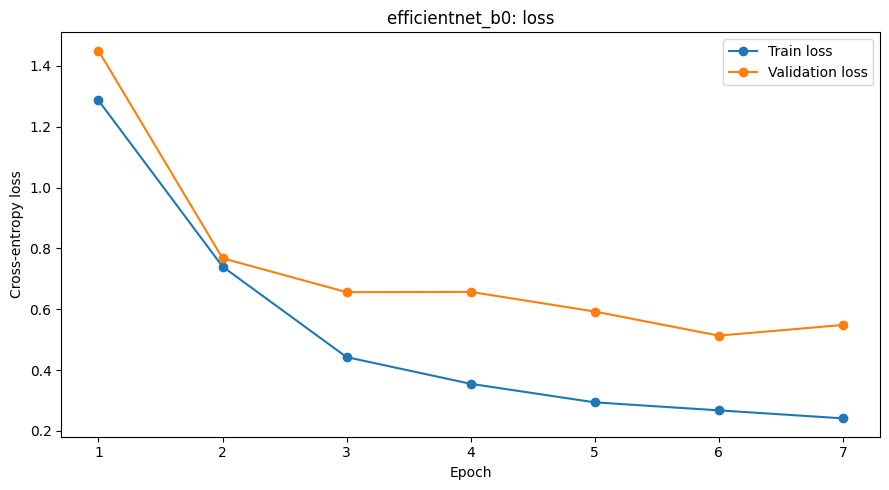

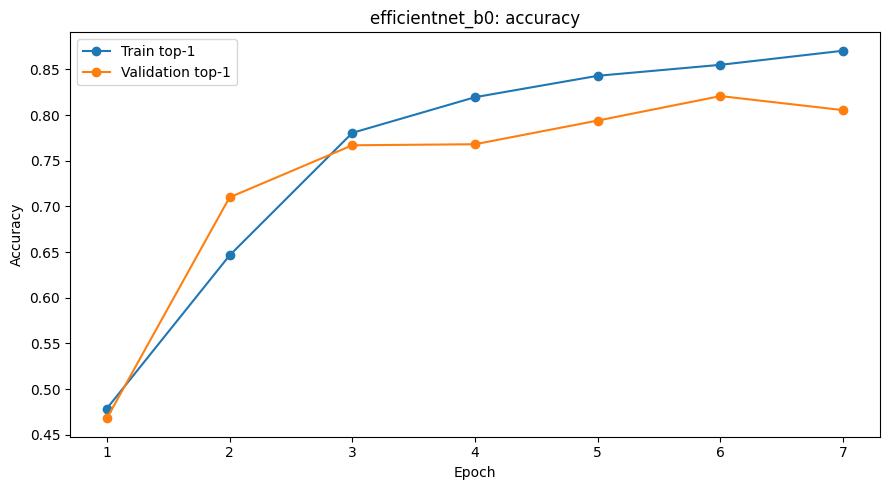

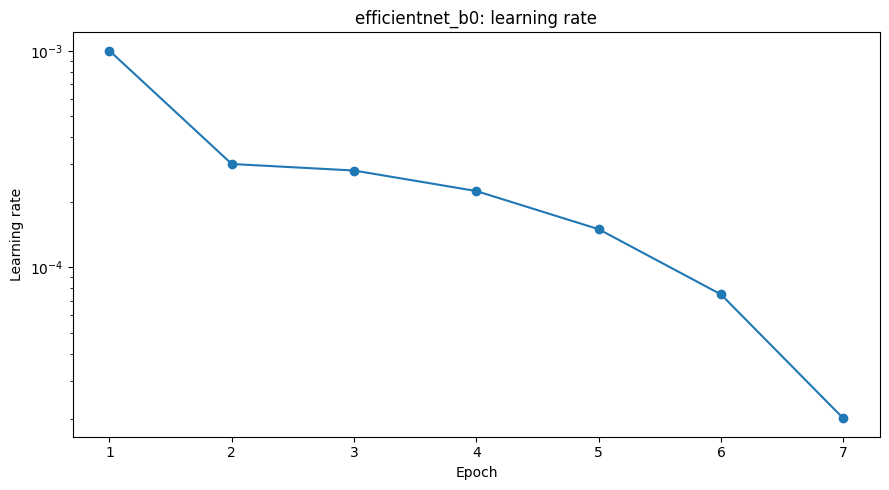

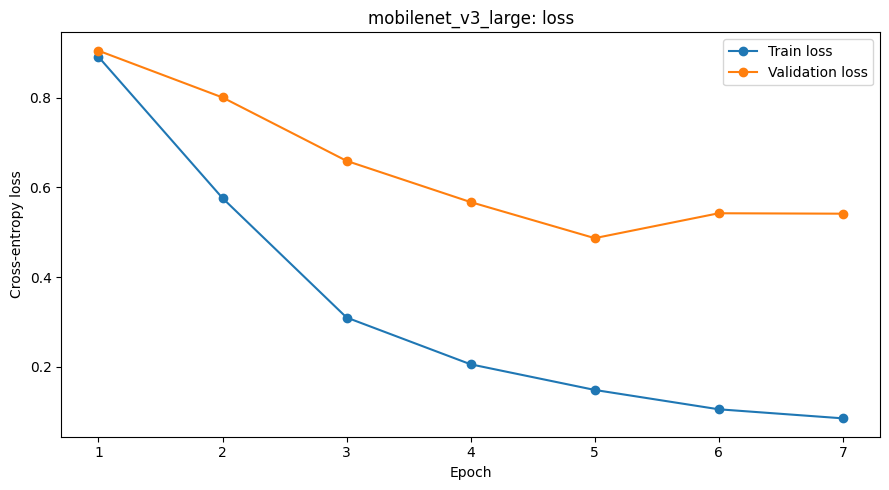

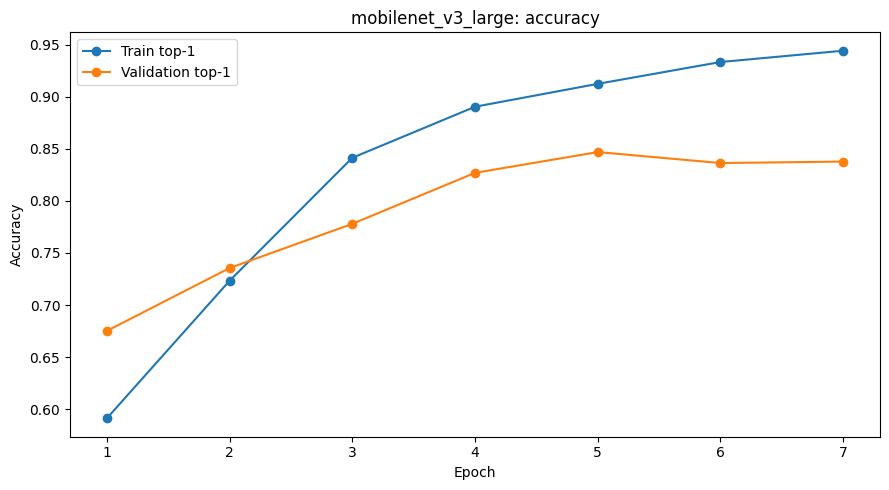

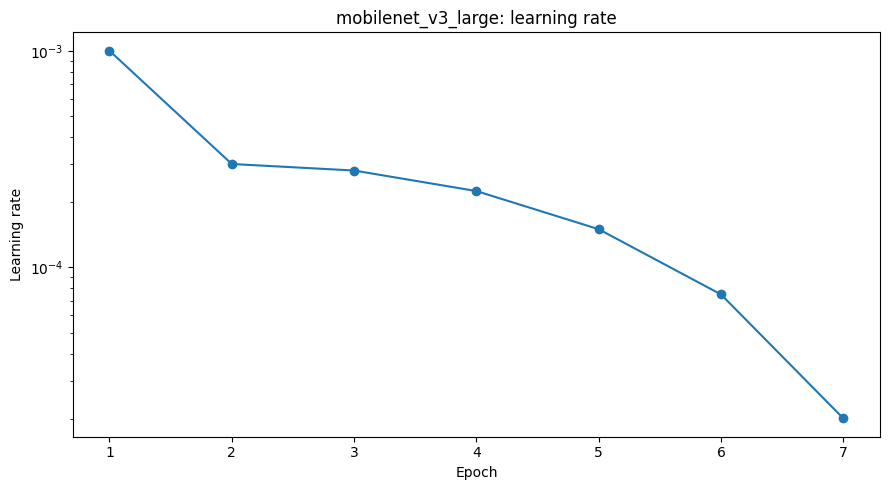

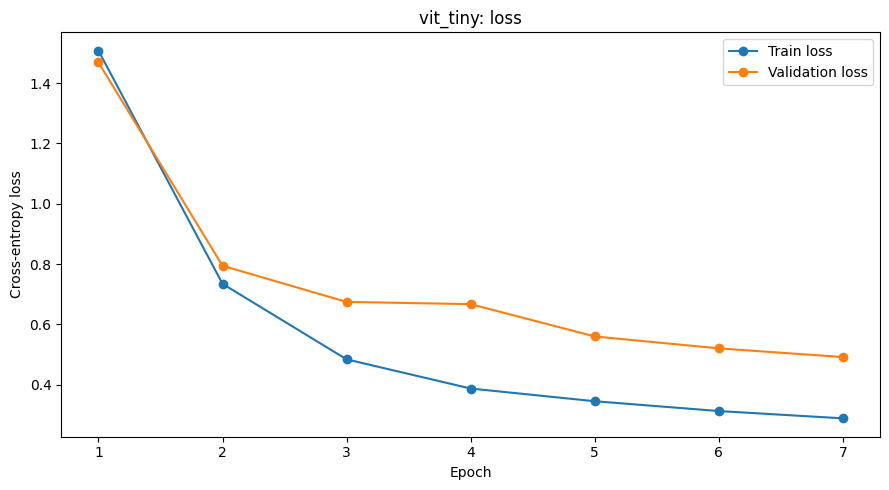

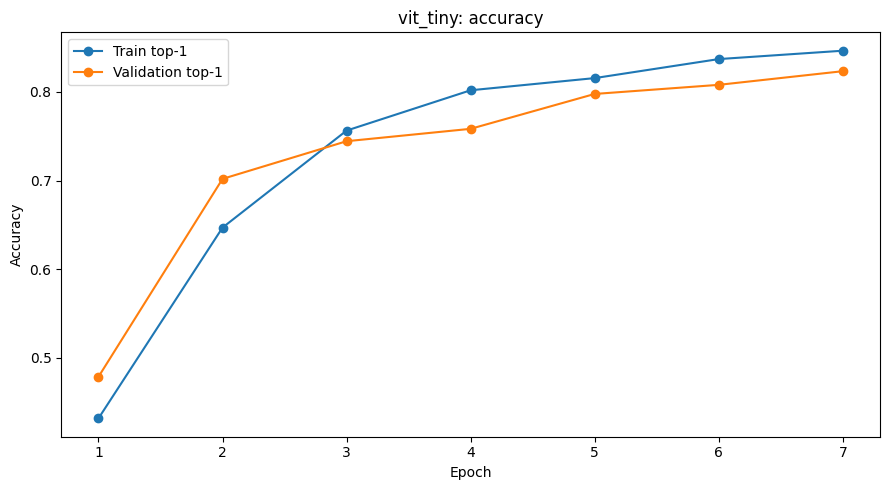

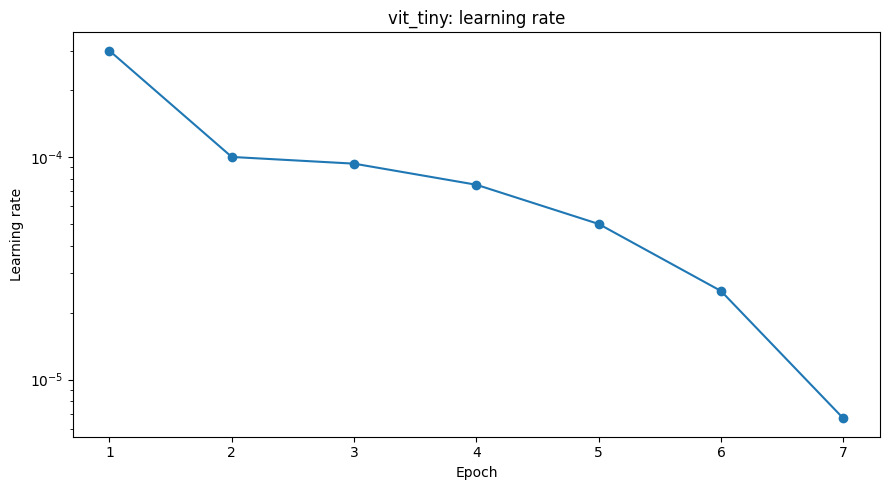

In [27]:
for model_name in final_models:
    candidates = list((RESULTS_ROOT / "logs").glob(f"final_{model_name}_*_history.csv"))
    if not candidates:
        continue
    hist = pd.read_csv(candidates[0])
    fig, ax = plt.subplots(figsize=(9, 5))
    ax.plot(hist["epoch"], hist["train_loss"], marker="o", label="Train loss")
    ax.plot(hist["epoch"], hist["val_loss"], marker="o", label="Validation loss")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Cross-entropy loss")
    ax.set_title(f"{model_name}: loss")
    ax.legend()
    fig.tight_layout()
    fig.savefig(RESULTS_ROOT / "figures" / f"{model_name}_loss_curve.png", dpi=220, bbox_inches="tight")
    plt.show()
    plt.close(fig)

    fig, ax = plt.subplots(figsize=(9, 5))
    ax.plot(hist["epoch"], hist["train_top1"], marker="o", label="Train top-1")
    ax.plot(hist["epoch"], hist["val_top1"], marker="o", label="Validation top-1")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Accuracy")
    ax.set_title(f"{model_name}: accuracy")
    ax.legend()
    fig.tight_layout()
    fig.savefig(RESULTS_ROOT / "figures" / f"{model_name}_accuracy_curve.png", dpi=220, bbox_inches="tight")
    plt.show()
    plt.close(fig)

    fig, ax = plt.subplots(figsize=(9, 5))
    ax.plot(hist["epoch"], hist["learning_rate"], marker="o")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Learning rate")
    ax.set_title(f"{model_name}: learning rate")
    ax.set_yscale("log")
    fig.tight_layout()
    fig.savefig(RESULTS_ROOT / "figures" / f"{model_name}_learning_rate_curve.png", dpi=220, bbox_inches="tight")
    plt.show()
    plt.close(fig)

## Confusion matrices

Because **9 labels** are present, the matrices use a compact square layout. The exact internal DeepWeeds class codes are placed on the axes. Raw counts are kept in CSV/NumPy outputs; the figure is mainly for visual comparison rather than precise reading of every cell.


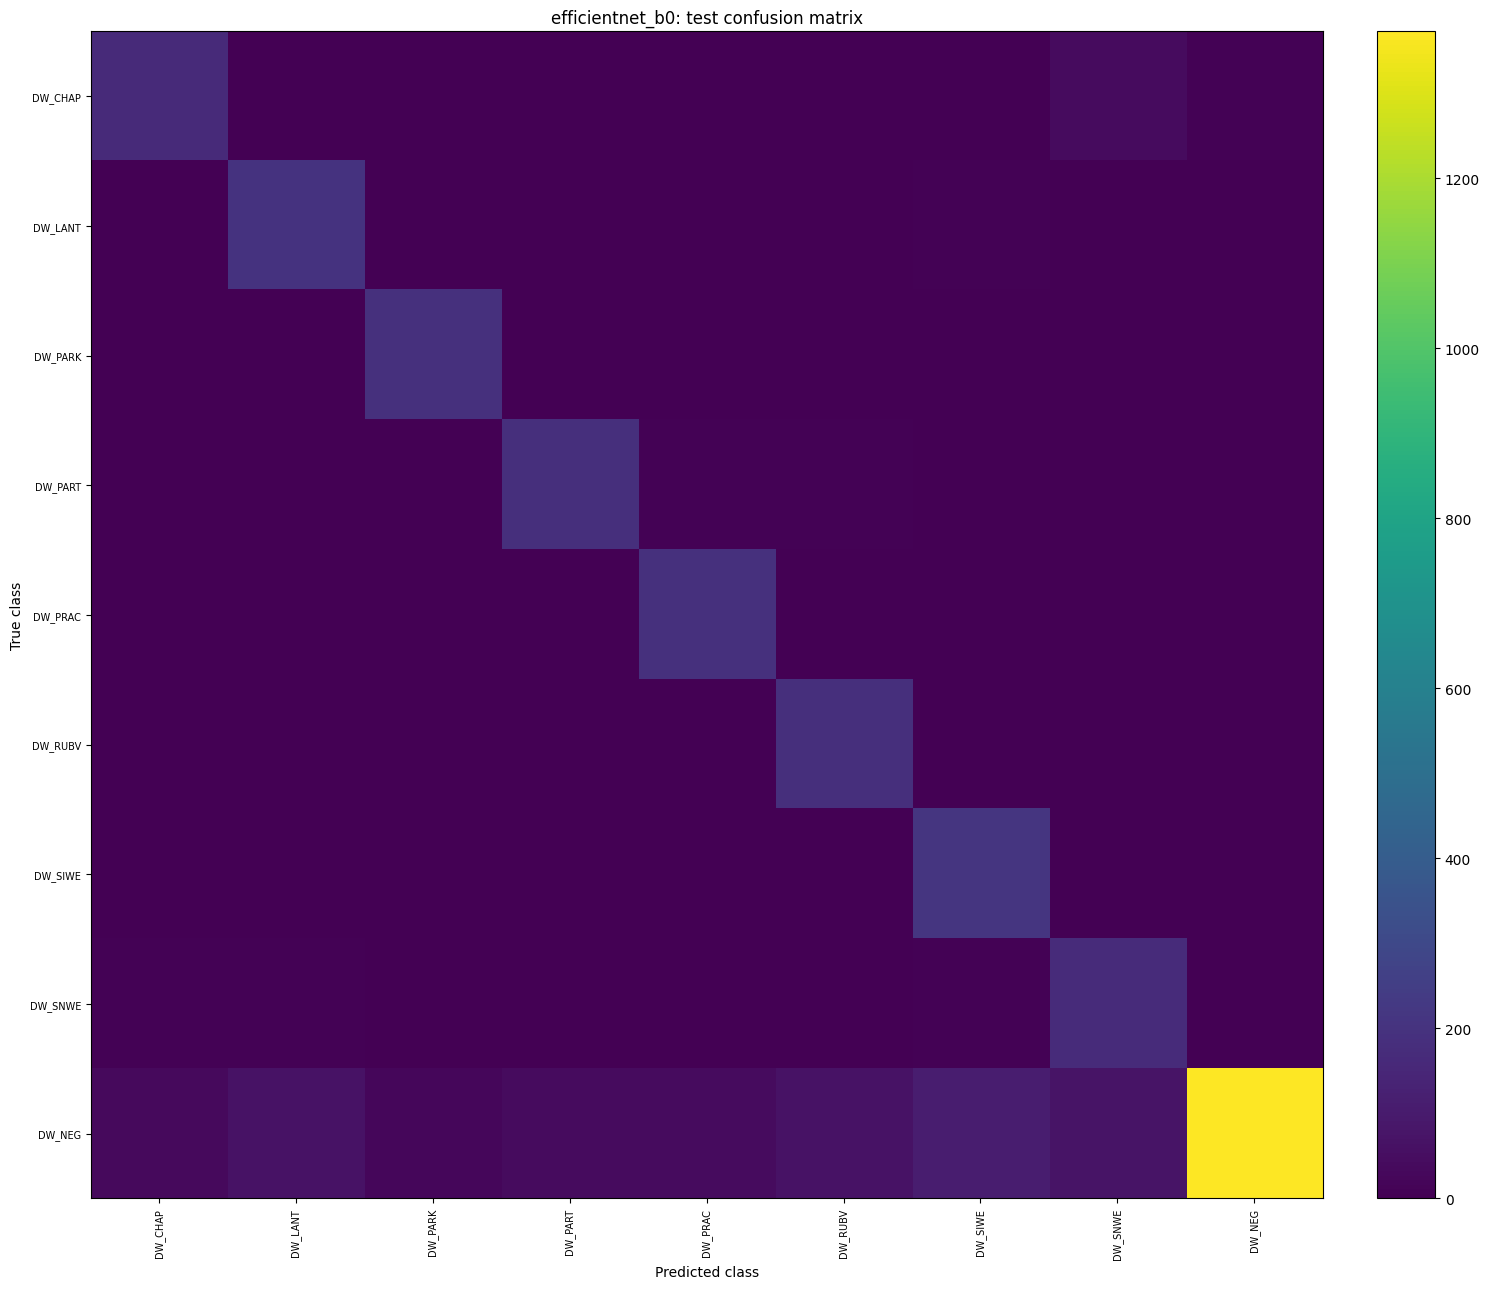

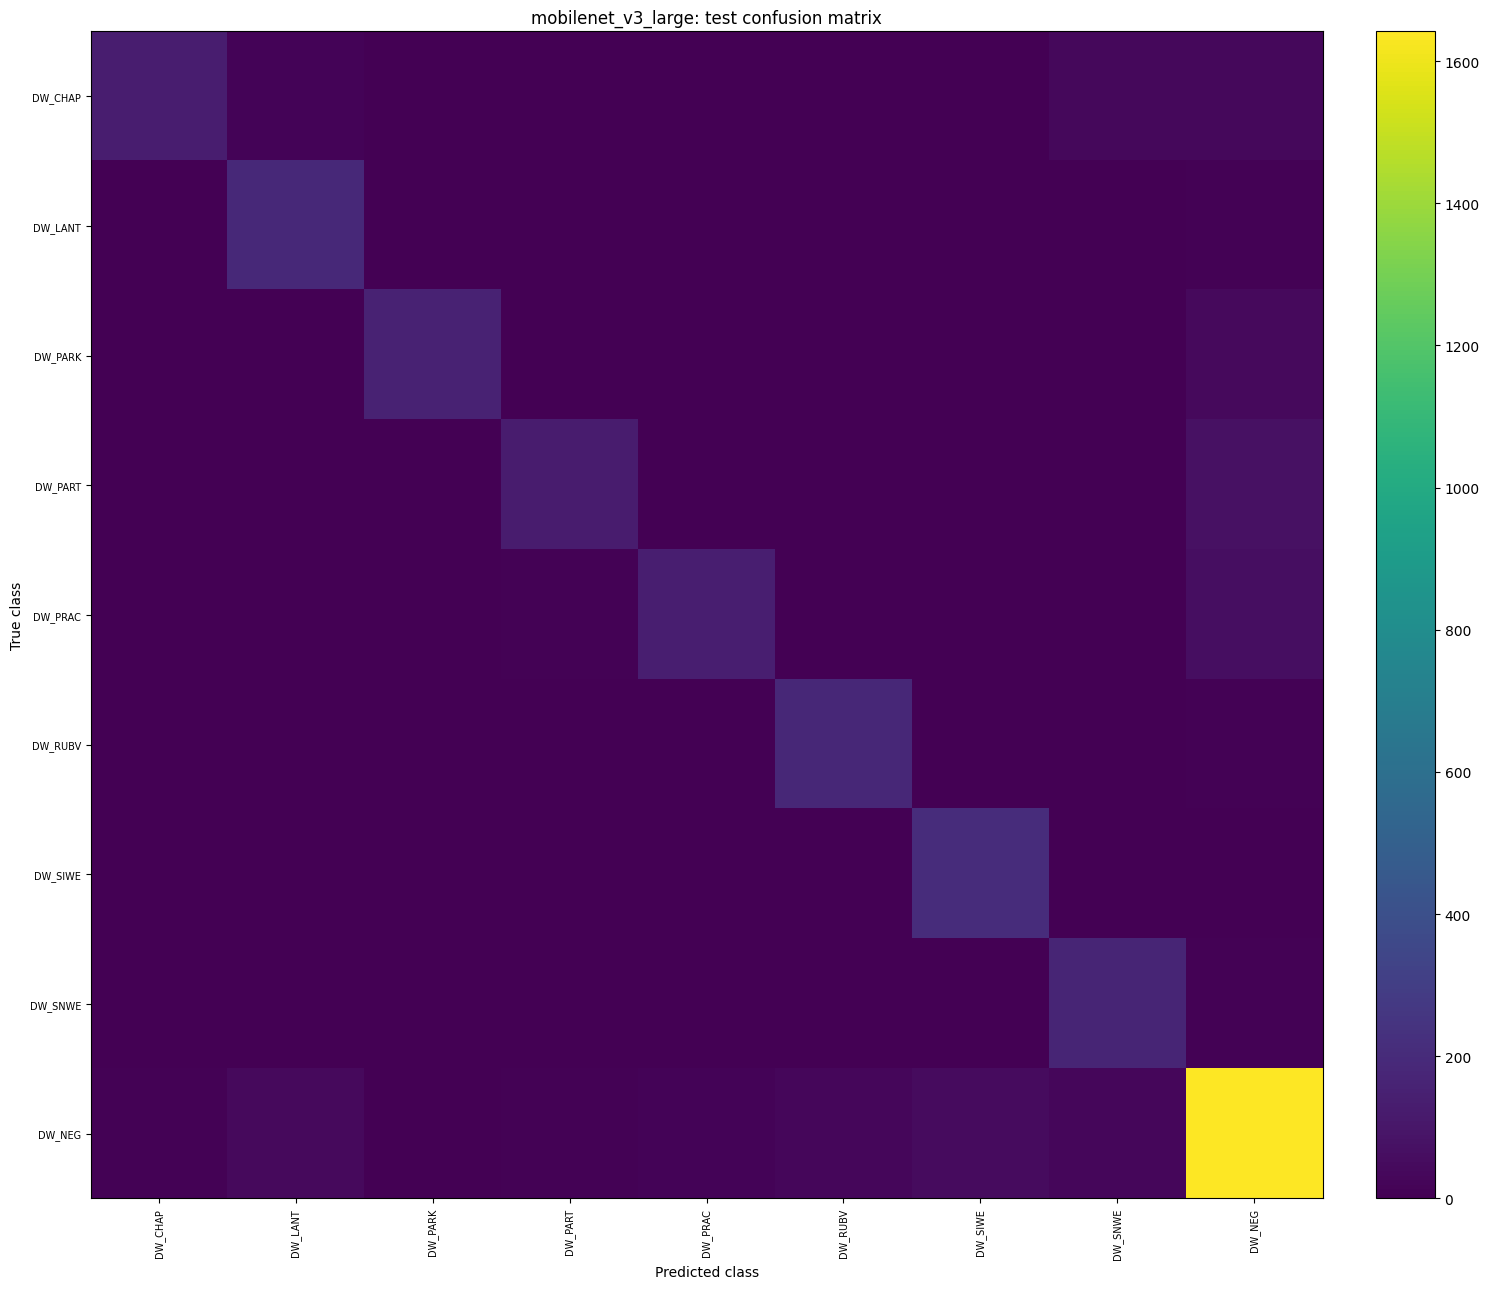

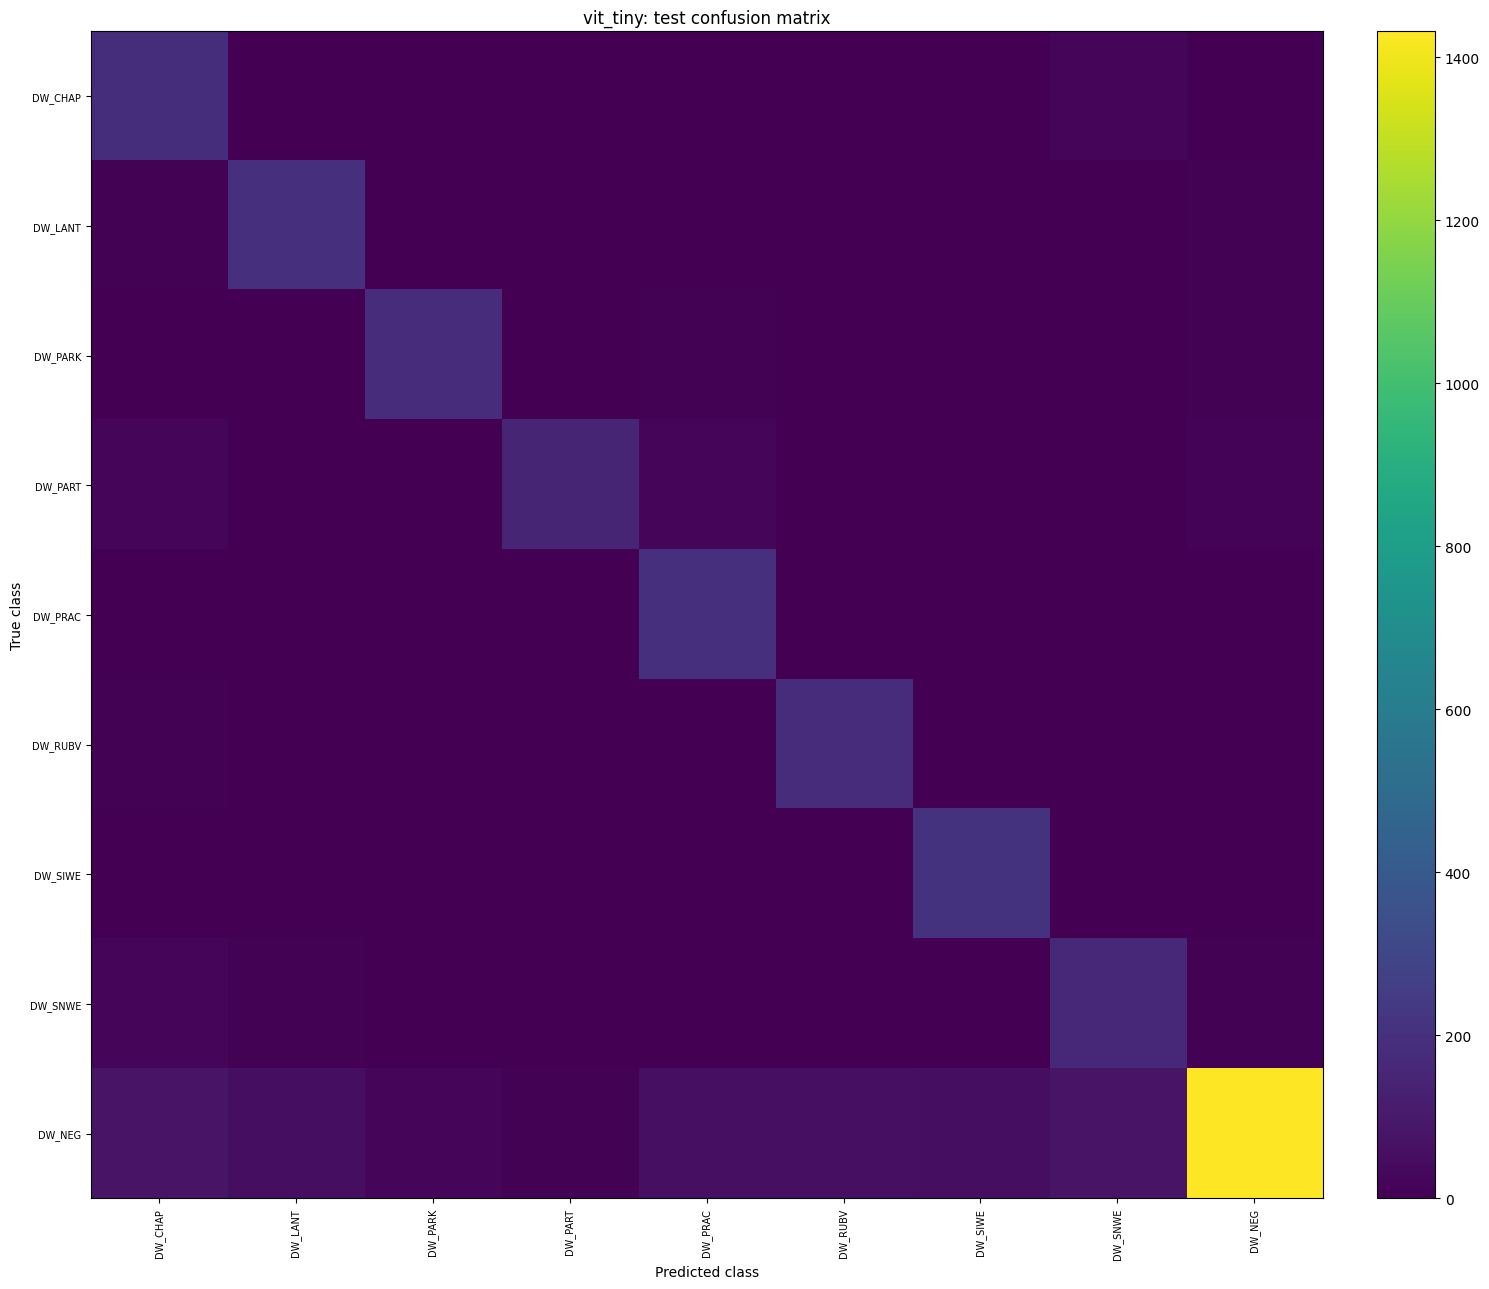

In [28]:
for model_name, cm in all_confusion.items():
    fig, ax = plt.subplots(figsize=(15, 13))
    im = ax.imshow(cm, interpolation="nearest", aspect="auto")
    ax.set_xlabel("Predicted class")
    ax.set_ylabel("True class")
    ax.set_title(f"{model_name}: test confusion matrix")
    ax.set_xticks(np.arange(len(SPECIES_CODES)))
    ax.set_yticks(np.arange(len(SPECIES_CODES)))
    ax.set_xticklabels(SPECIES_CODES, rotation=90, fontsize=7)
    ax.set_yticklabels(SPECIES_CODES, fontsize=7)
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    fig.tight_layout()
    fig.savefig(RESULTS_ROOT / "figures" / f"{model_name}_confusion_matrix.png", dpi=240, bbox_inches="tight")
    plt.show()
    plt.close(fig)
    np.save(RESULTS_ROOT / "metrics" / f"{model_name}_confusion_matrix.npy", cm)

## Error analysis

The notebook reports observed model behavior without assigning biological causes that were not tested. It highlights the most frequent class confusions, low-recall classes, and high-confidence incorrect predictions.


In [29]:
for model_name, per_class in all_per_class.items():
    cls = per_class[per_class["class"].isin(SPECIES_CODES)].copy()
    cls["recall"] = pd.to_numeric(cls["recall"], errors="coerce")
    cls["precision"] = pd.to_numeric(cls["precision"], errors="coerce")
    print(f"\n{model_name}: lowest-recall species")
    display(cls.sort_values("recall").head(10)[["class", "precision", "recall", "f1-score", "support"]])

    pred_path = RESULTS_ROOT / "predictions" / f"final_{model_name}_predictions.csv"
    pred_frame = pd.read_csv(pred_path)
    pred_frame["confidence"] = pred_frame["predicted_probability"]
    errors = pred_frame[~pred_frame["correct"]].sort_values("confidence", ascending=False).head(25)
    errors.to_csv(RESULTS_ROOT / "metrics" / f"{model_name}_confident_errors.csv", index=False)
    print(f"{model_name}: top confident errors")
    display(errors[["path", "ground_truth_eppo", "predicted_eppo", "confidence"]].head(10))

# Find the most frequent off-diagonal confusions for the best test model.
if not model_comparison.empty:
    best_model = str(model_comparison.iloc[0]["Model"])
    cm = all_confusion[best_model].copy()
    pairs = []
    for i in range(len(SPECIES_CODES)):
        for j in range(len(SPECIES_CODES)):
            if i != j and cm[i, j] > 0:
                pairs.append({"true": INDEX_TO_CLASS[i], "predicted": INDEX_TO_CLASS[j], "count": int(cm[i, j])})
    confusion_pairs = pd.DataFrame(pairs).sort_values("count", ascending=False)
    confusion_pairs.to_csv(RESULTS_ROOT / "metrics" / "most_confused_pairs.csv", index=False)
    print("Most frequent observed confusion pairs for best model:", best_model)
    display(confusion_pairs.head(20))


efficientnet_b0: lowest-recall species


,class,precision,recall,f1-score,support
0,DW_CHAP,0.752294,0.725664,0.738739,226.0
8,DW_NEG,0.980014,0.749454,0.849366,1832.0
7,DW_SNWE,0.579310,0.861538,0.692784,195.0
3,DW_PART,0.779661,0.863850,0.819599,213.0
4,DW_PRAC,0.786885,0.914286,0.845815,210.0
2,DW_PARK,0.857143,0.941176,0.897196,204.0
1,DW_LANT,0.716846,0.943396,0.814664,212.0
5,DW_RUBV,0.685185,0.948718,0.795699,195.0
6,DW_SIWE,0.618076,0.972477,0.755793,218.0


efficientnet_b0: top confident errors


,path,ground_truth_eppo,predicted_eppo,confidence
2577,/content/drive/MyDrive/DeepWeeds/dataset/20180...,DW_SNWE,DW_SIWE,0.999944
169,/content/drive/MyDrive/DeepWeeds/dataset/20170...,DW_SNWE,DW_CHAP,0.999933
786,/content/drive/MyDrive/DeepWeeds/dataset/20170...,DW_NEG,DW_PRAC,0.999924
2376,/content/drive/MyDrive/DeepWeeds/dataset/20180...,DW_NEG,DW_SIWE,0.999551
677,/content/drive/MyDrive/DeepWeeds/dataset/20170...,DW_NEG,DW_PRAC,0.999469
788,/content/drive/MyDrive/DeepWeeds/dataset/20170...,DW_NEG,DW_PRAC,0.998808
781,/content/drive/MyDrive/DeepWeeds/dataset/20170...,DW_NEG,DW_PRAC,0.997780
2562,/content/drive/MyDrive/DeepWeeds/dataset/20180...,DW_NEG,DW_SIWE,0.997569
3287,/content/drive/MyDrive/DeepWeeds/dataset/20180...,DW_NEG,DW_SIWE,0.996135
790,/content/drive/MyDrive/DeepWeeds/dataset/20170...,DW_NEG,DW_PRAC,0.995307



mobilenet_v3_large: lowest-recall species


...

,class,precision,recall,f1-score,support
3,DW_PART,0.937888,0.708920,0.807487,213.0
8,DW_NEG,0.969533,0.781659,0.865518,1832.0
7,DW_SNWE,0.594096,0.825641,0.690987,195.0
0,DW_CHAP,0.584375,0.827434,0.684982,226.0
2,DW_PARK,0.878049,0.882353,0.880196,204.0
1,DW_LANT,0.740458,0.915094,0.818565,212.0
5,DW_RUBV,0.745902,0.933333,0.829157,195.0
4,DW_PRAC,0.681507,0.947619,0.792829,210.0
6,DW_SIWE,0.772894,0.967890,0.859470,218.0


vit_tiny: top confident errors


,path,ground_truth_eppo,predicted_eppo,confidence
774,/content/drive/MyDrive/DeepWeeds/dataset/20170...,DW_NEG,DW_PRAC,0.997442
2506,/content/drive/MyDrive/DeepWeeds/dataset/20180...,DW_NEG,DW_SIWE,0.997414
169,/content/drive/MyDrive/DeepWeeds/dataset/20170...,DW_SNWE,DW_CHAP,0.996508
767,/content/drive/MyDrive/DeepWeeds/dataset/20170...,DW_NEG,DW_PRAC,0.995259
778,/content/drive/MyDrive/DeepWeeds/dataset/20170...,DW_NEG,DW_PRAC,0.995184
2643,/content/drive/MyDrive/DeepWeeds/dataset/20180...,DW_SNWE,DW_CHAP,0.995023
2577,/content/drive/MyDrive/DeepWeeds/dataset/20180...,DW_SNWE,DW_SIWE,0.993611
1949,/content/drive/MyDrive/DeepWeeds/dataset/20171...,DW_NEG,DW_LANT,0.992480
2145,/content/drive/MyDrive/DeepWeeds/dataset/20171...,DW_NEG,DW_PRAC,0.991688
792,/content/drive/MyDrive/DeepWeeds/dataset/20170...,DW_NEG,DW_PRAC,0.990365


Most frequent observed confusion pairs for best model: mobilenet_v3_large


,true,predicted,count
20,DW_PART,DW_NEG,71
27,DW_PRAC,DW_NEG,58
45,DW_NEG,DW_SIWE,50
12,DW_PARK,DW_NEG,40
40,DW_NEG,DW_LANT,39
5,DW_CHAP,DW_NEG,36
4,DW_CHAP,DW_SNWE,36
46,DW_NEG,DW_SNWE,31
44,DW_NEG,DW_RUBV,31
43,DW_NEG,DW_PRAC,18


### Selected misclassified examples

The code below builds a compact figure from the highest-confidence errors for the best model. The montage uses only observed predictions, so visual interpretation should be cautious because no biological causal analysis is performed here.


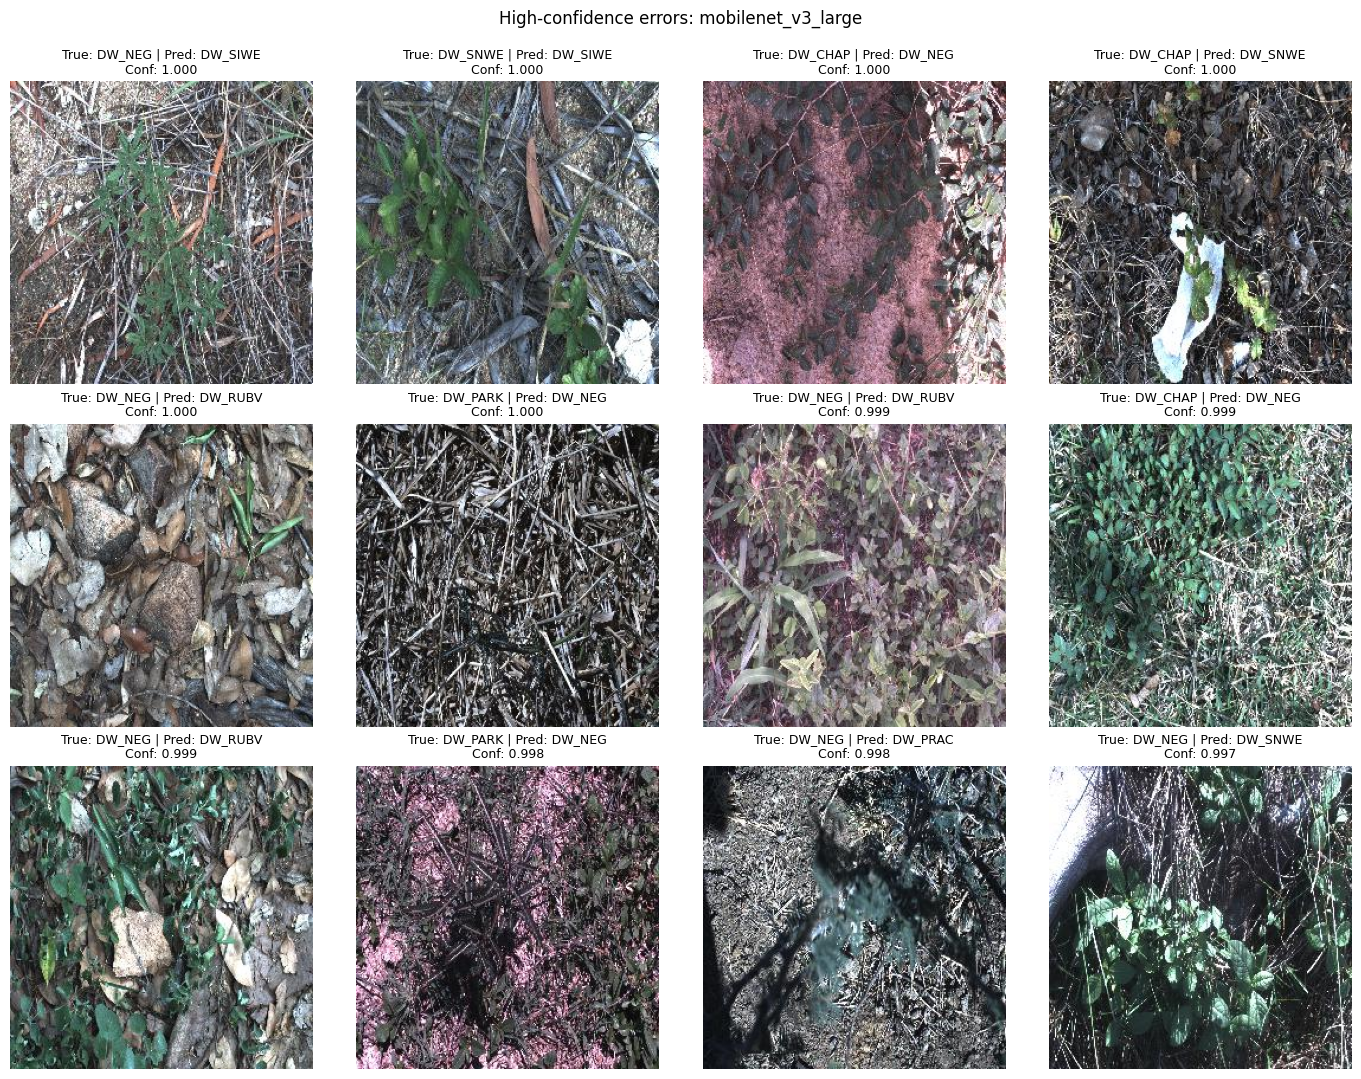

In [30]:
if not model_comparison.empty:
    best_model = str(model_comparison.iloc[0]["Model"])
    error_csv = RESULTS_ROOT / "metrics" / f"{best_model}_confident_errors.csv"
    error_rows = pd.read_csv(error_csv).head(12)
    if not error_rows.empty:
        ncols = 4
        nrows = math.ceil(len(error_rows) / ncols)
        fig, axes = plt.subplots(nrows, ncols, figsize=(14, 3.6 * nrows))
        axes = np.asarray(axes).reshape(-1)
        for ax, (_, row) in zip(axes, error_rows.iterrows()):
            try:
                with Image.open(row["path"]) as im:
                    ax.imshow(im.convert("RGB"))
                ax.set_title(f"True: {row['ground_truth_eppo']} | Pred: {row['predicted_eppo']}\nConf: {row['confidence']:.3f}", fontsize=9)
            except Exception as exc:
                ax.text(0.5, 0.5, f"Could not load\n{exc}", ha="center", va="center")
            ax.axis("off")
        for ax in axes[len(error_rows):]:
            ax.axis("off")
        fig.suptitle(f"High-confidence errors: {best_model}", y=0.995)
        fig.tight_layout()
        fig.savefig(RESULTS_ROOT / "figures" / f"{best_model}_error_montage.png", dpi=220, bbox_inches="tight")
        plt.show()
        plt.close(fig)

## Statistical reporting

This run uses one fixed random seed by default to keep the normal Colab experiment practical. When multiple seeds are enabled, the following cell aggregates results using mean, standard deviation, minimum, and maximum. No confidence interval or statistical-significance claim is made unless a dedicated test is added.


## Runtime report

The notebook saves experiment-level elapsed time and provides a concise runtime summary.


In [31]:
def summarize_repeated_runs(frame: pd.DataFrame, metric_columns: list[str]) -> pd.DataFrame:
    if frame.empty or frame["seed"].nunique() < 2:
        print("Only one seed is present; mean/std/min/max across seeds are not meaningful yet.")
        return pd.DataFrame()
    rows = []
    for model_name, group in frame.groupby("Model"):
        row = {"Model": model_name, "Seeds": int(group["seed"].nunique())}
        for metric in metric_columns:
            row[f"{metric} mean"] = group[metric].mean()
            row[f"{metric} std"] = group[metric].std(ddof=1)
            row[f"{metric} min"] = group[metric].min()
            row[f"{metric} max"] = group[metric].max()
        rows.append(row)
    return pd.DataFrame(rows)


# The default run uses one seed. This cell can also aggregate additional seed runs.
seed_results_placeholder = model_comparison.copy()
if not seed_results_placeholder.empty:
    seed_results_placeholder["seed"] = SEED
stats_table = summarize_repeated_runs(seed_results_placeholder, ["Top-1 Accuracy", "Macro F1", "Weighted F1"])
if not stats_table.empty:
    stats_table.to_csv(RESULTS_ROOT / "tables" / "seed_statistics.csv", index=False)
    display(stats_table)

Only one seed is present; mean/std/min/max across seeds are not meaningful yet.


In [32]:
runtime_rows = []
for p in (RESULTS_ROOT / "logs").glob("final_*_history.csv"):
    try:
        hist = pd.read_csv(p)
        runtime_rows.append({
            "Experiment": p.stem.replace("_history", ""),
            "Epochs": int(hist["epoch"].max()),
            "Logged training+validation seconds": float(hist["epoch_seconds"].sum()),
        })
    except Exception as exc:
        print(f"Skipping unreadable runtime log {p.name}: {exc}")
runtime_table = pd.DataFrame(runtime_rows)
if not runtime_table.empty:
    runtime_table.to_csv(RESULTS_ROOT / "tables" / "runtime_summary.csv", index=False)
    display(runtime_table)
    print(f"Total logged model runtime: {runtime_table['Logged training+validation seconds'].sum():.1f}s")

,Experiment,Epochs,Logged training+validation seconds
0,final_vit_tiny_lr3e-4,7,1200.128936
1,final_efficientnet_b0_lr1e-3,7,1042.238149
2,final_mobilenet_v3_large_lr1e-3,7,1009.749993


Total logged model runtime: 3252.1s


# Quality-control and artifact audit

The executable audit performs thirteen lightweight runtime passes covering dependencies, dataflow, tensor shapes, scientific split isolation, metric sanity, performance instrumentation, memory hygiene, reproducibility, edge cases, and artifact completeness. A separate pre-delivery static parse checks every code cell before the optimized notebook is returned.


In [34]:
# ---------------------------------------------------------------------------
# Final quality-control and artifact audit
# ---------------------------------------------------------------------------
# This notebook runs fourteen lightweight validation passes here. These are
# executable runtime checks; the separate pre-delivery audit also statically
# parses every notebook code cell before the optimized .ipynb is returned.

validation_report = []
required_result_dirs = [
    RESULTS_ROOT / "figures",
    RESULTS_ROOT / "tables",
    RESULTS_ROOT / "metrics",
    RESULTS_ROOT / "checkpoints",
    RESULTS_ROOT / "logs",
    RESULTS_ROOT / "configs",
]


def _qc_pass(number: int, name: str, check) -> None:
    try:
        detail = check()
        validation_report.append({
            "pass": int(number),
            "name": name,
            "status": "PASS",
            "detail": str(detail),
        })
    except Exception as exc:
        validation_report.append({
            "pass": int(number),
            "name": name,
            "status": "FAIL",
            "detail": repr(exc),
        })
        raise


_qc_pass(
    1,
    "Structure / required runtime objects",
    lambda: f"classes={len(SPECIES_CODES)}, result_root={RESULTS_ROOT}",
)

_qc_pass(
    2,
    "Import / dependency surface",
    lambda: f"torch={torch.__version__}, timm={timm.__version__}, sklearn={__import__('sklearn').__version__}",
)

_qc_pass(
    3,
    "Variable / function dependency availability",
    lambda: (
        f"build_model={callable(build_model)}, "
        f"run_epoch={callable(run_epoch)}, "
        f"evaluate_predictions={callable(evaluate_predictions)}, "
        f"build_model_transforms={callable(build_model_transforms)}"
    ),
)


def _transform_profile_check():
    profiles = {}
    for model_name in MODEL_CONFIGS:
        train_tf, eval_tf = build_model_transforms(model_name)
        assert callable(train_tf)
        assert callable(eval_tf)
        mean, std = MODEL_NORMALIZATION[model_name]
        assert len(mean) == 3 and len(std) == 3
        profiles[model_name] = {"mean": mean, "std": std}

    assert profiles["vit_tiny"]["mean"] == (0.5, 0.5, 0.5)
    assert profiles["efficientnet_b0"]["mean"] == IMAGENET_MEAN

    return profiles


_qc_pass(
    4,
    "Pretrained transform profile",
    _transform_profile_check,
)


_qc_pass(
    5,
    "Runtime dataflow availability",
    lambda: (
        f"train={len(train_ds):,}, val={len(val_ds):,}, test={len(test_ds):,}"
    ),
)


def _shape_dtype_check():
    batch = next(iter(test_loader))
    images, labels, paths = batch

    assert (
        images.ndim == 4
        and images.shape[1:] == (3, IMAGE_SIZE, IMAGE_SIZE)
    )
    assert labels.ndim == 1
    assert labels.dtype == torch.int64
    assert len(paths) == images.shape[0]

    return (
        f"images={tuple(images.shape)}, "
        f"labels={tuple(labels.shape)}, "
        f"dtype={images.dtype}"
    )


_qc_pass(
    6,
    "Tensor shape / dtype",
    _shape_dtype_check,
)


def _science_split_check():
    assert set(metadata["eppo"]) == set(SPECIES_CODES)
    assert metadata["group_id"].isna().sum() == 0

    for a, b in (("train", "val"), ("train", "test"), ("val", "test")):
        A = set(metadata.loc[metadata["split"] == a, "group_id"])
        B = set(metadata.loc[metadata["split"] == b, "group_id"])

        assert not A.intersection(B), f"group leakage {a}/{b}"

    return (
        f"grouping={metadata['group_id'].nunique():,}; "
        "overlaps=0"
    )


_qc_pass(
    7,
    "Scientific split / leakage",
    _science_split_check,
)


def _metrics_check():
    if model_comparison.empty:
        return "No final models were run; metric check skipped."

    required = {
        "Top-1 Accuracy",
        "Macro F1",
        "Weighted F1",
    }

    assert required.issubset(model_comparison.columns)

    assert np.isfinite(
        model_comparison[
            list(required)
        ].to_numpy(dtype=float)
    ).all()

    return (
        f"models={len(model_comparison)}; "
        "metrics finite"
    )


_qc_pass(
    8,
    "Metric calculation outputs",
    _metrics_check,
)


def _performance_instrumentation_check():
    history_files = sorted(
        (RESULTS_ROOT / "logs").glob("final_*_history.csv")
    )

    if not history_files:
        return (
            "No final history files exist because "
            "final training produced no runs."
        )

    required_columns = {
        "epoch_seconds",
        "train_samples_per_second",
        "val_samples_per_second",
        "peak_vram_mb",
    }

    checked = 0

    for history_path in history_files:
        history = pd.read_csv(history_path)

        missing = required_columns.difference(history.columns)

        assert not missing, (
            f"{history_path.name} missing {sorted(missing)}"
        )

        assert np.isfinite(
            history[
                list(required_columns)
            ]
            .replace([np.inf, -np.inf], np.nan)
            .dropna()
            .to_numpy(dtype=float)
        ).all()

        checked += 1

    return (
        f"checked={checked}; "
        "required throughput/VRAM fields present and finite"
    )


_qc_pass(
    9,
    "Performance instrumentation",
    _performance_instrumentation_check,
)


def _memory_hygiene_check():
    resident_on_gpu = []

    for model_name, model in final_models.items():
        devices = {
            str(p.device)
            for p in model.parameters()
        }

        assert devices <= {"cpu"}, (
            f"{model_name} retained parameters on {devices}"
        )

        resident_on_gpu.append(model_name)

    allocated_mb = (
        float(
            torch.cuda.memory_allocated()
            / (1024**2)
        )
        if torch.cuda.is_available()
        else 0.0
    )

    return (
        f"final_models_on_cpu={len(resident_on_gpu)}; "
        f"current_allocated_vram={allocated_mb:.1f} MB"
    )


_qc_pass(
    10,
    "Memory / VRAM hygiene",
    _memory_hygiene_check,
)


_qc_pass(
    11,
    "Reproducibility configuration",
    lambda: (
        f"seed={SEED}; "
        f"strict_determinism={STRICT_DETERMINISM}; "
        f"split_checksum="
        f"{sha if 'sha' in globals() else 'not-yet-generated'}"
    ),
)


def _edge_case_helper_check():
    # Run a small numerical sanity check for the class-weight helper and top-k logic.
    tiny = pd.DataFrame({
        "class_index": list(range(len(SPECIES_CODES)))
    })

    w = compute_balanced_weights(tiny)

    assert w.shape[0] == len(SPECIES_CODES)

    test_logits = torch.tensor([
        [3.0, 2.0, 1.0],
        [0.1, 1.0, 0.2],
    ])

    test_labels = torch.tensor([0, 2])

    assert (
        0.5
        <= topk_accuracy(
            test_logits,
            test_labels,
            3,
        )
        <= 1.0
    )

    return (
        "class weights and top-k helper "
        "sanity checks passed"
    )


_qc_pass(
    12,
    "Edge cases / numerical sanity",
    _edge_case_helper_check,
)


def _artifact_check():
    for path in required_result_dirs:
        assert path.is_dir(), (
            f"Missing result directory: {path}"
        )

    expected = [
        RESULTS_ROOT / "tables" / "dataset_summary.csv",
        RESULTS_ROOT / "tables" / "split_metadata.csv",
        RESULTS_ROOT / "configs" / "split_metadata.sha256",
        RESULTS_ROOT / "configs" / "split_config.json",
    ]

    for path in expected:
        assert path.exists(), (
            f"Missing required artifact: {path}"
        )

    return (
        "required result tree and "
        "split/config artifacts exist"
    )


def _optimizer_group_check():
    class _DummyEfficientNetLike(nn.Module):
        def __init__(self):
            super().__init__()

            # IMPORTANT:
            # freeze_for_stage() uses model.features[-2:].
            # The test double therefore needs a sliceable
            # Sequential feature container that matches the structural
            # contract of torchvision EfficientNet.
            self.features = nn.Sequential(
                nn.Linear(4, 4),
                nn.ReLU(),
                nn.Linear(4, 4),
            )

            # Mirror the real EfficientNet classifier structure and
            # preserve the "classifier." prefix expected by
            # build_optimizer().
            self.classifier = nn.Sequential(
                nn.Dropout(p=0.0),
                nn.Linear(4, len(SPECIES_CODES)),
            )

    dummy = _DummyEfficientNetLike()

    freeze_for_stage(
        model=dummy,
        model_name="efficientnet_b0",
        stage="finetune",
    )

    # Confirm that fine-tuning exposes backbone parameters.
    trainable_backbone = [
        name
        for name, param in dummy.named_parameters()
        if (
            param.requires_grad
            and name.startswith("features.")
        )
    ]

    # Confirm that the classifier/head remains trainable.
    trainable_head = [
        name
        for name, param in dummy.named_parameters()
        if (
            param.requires_grad
            and name.startswith("classifier.")
        )
    ]

    assert trainable_backbone, (
        "Fine-tune stage did not unfreeze "
        "EfficientNet backbone parameters."
    )

    assert trainable_head, (
        "Fine-tune stage did not keep "
        "classifier parameters trainable."
    )

    optimizer = build_optimizer(
        model=dummy,
        model_name="efficientnet_b0",
        stage="finetune",
        backbone_lr=1e-4,
        head_lr=5e-4,
        weight_decay=1e-4,
    )

    lrs = sorted(
        float(group["lr"])
        for group in optimizer.param_groups
    )

    assert lrs == [1e-4, 5e-4], (
        f"Unexpected optimizer learning rates: {lrs}"
    )

    return (
        "fine-tune parameter groups validated; "
        f"backbone_lr={1e-4:.1e}, "
        f"head_lr={5e-4:.1e}; "
        f"backbone_params={len(trainable_backbone)}, "
        f"head_params={len(trainable_head)}"
    )


_qc_pass(
    13,
    "Discriminative optimizer groups",
    _optimizer_group_check,
)


_qc_pass(
    14,
    "Artifact completeness",
    _artifact_check,
)


validation_df = pd.DataFrame(validation_report)

validation_df.to_csv(
    RESULTS_ROOT / "metrics" / "validation_passes.csv",
    index=False,
)

(RESULTS_ROOT / "metrics" / "validation_passes.json").write_text(
    json.dumps(
        validation_report,
        indent=2,
    ),
    encoding="utf-8",
)

print("Validation report")
display(validation_df)

assert (
    validation_df["status"] == "PASS"
).all(), validation_report


# The test loader is needed for the tensor-shape QC pass above,
# so its workers are released only after all QC passes are complete.
shutdown_loader_workers(test_loader)

print("All 14 executable QC passes passed.")

Validation report


,pass,name,status,detail
0,1,Structure / required runtime objects,PASS,"classes=9, result_root=/content/multi_species_..."
1,2,Import / dependency surface,PASS,"torch=2.11.0+cu128, timm=1.0.28, sklearn=1.6.1"
2,3,Variable / function dependency availability,PASS,"build_model=True, run_epoch=True, evaluate_pre..."
3,4,Pretrained transform profile,PASS,"{'efficientnet_b0': {'mean': (0.485, 0.456, 0...."
4,5,Runtime dataflow availability,PASS,"train=10,495, val=3,509, test=3,505"
5,6,Tensor shape / dtype,PASS,"images=(64, 3, 224, 224), labels=(64,), dtype=..."
6,7,Scientific split / leakage,PASS,"grouping=17,204; overlaps=0"
7,8,Metric calculation outputs,PASS,models=3; metrics finite
8,9,Performance instrumentation,PASS,checked=3; required throughput/VRAM fields pre...
9,10,Memory / VRAM hygiene,PASS,final_models_on_cpu=3; current_allocated_vram=...


All 14 executable QC passes passed.


## Automatic result packaging

The export helper is defined in the next cell but **is not executed until the final cell**. This keeps the last cell as the definitive artifact collection and download center.


In [35]:
import zipfile


ZIP_PATH = WORK_ROOT / "final_results.zip"


def _known_result_dataframes() -> dict[str, pd.DataFrame]:
    names = [
        "model_comparison",
        "pilot_df",
        "final_train_df",
        "runtime_table",
        "stats_table",
        "split_counts",
        "split_class",
        "class_stats",
        "summary",
        "confusion_pairs",
        "validation_df",
    ]
    out = {}
    for name in names:
        value = globals().get(name)
        if isinstance(value, pd.DataFrame) and not value.empty:
            out[name] = value
    return out


def package_final_results() -> dict[str, Any]:
    """
    Capture currently available figures/tables, write a reproducible README
    and final report, validate required artifacts, and create the ZIP.
    """
    figures_dir = RESULTS_ROOT / "figures"
    tables_dir = RESULTS_ROOT / "tables"
    metrics_dir = RESULTS_ROOT / "metrics"
    configs_dir = RESULTS_ROOT / "configs"

    for path in (figures_dir, tables_dir, metrics_dir, configs_dir):
        path.mkdir(parents=True, exist_ok=True)

    # Capture any Matplotlib figures that are still open.
    open_figures = []
    for fig_num in plt.get_fignums():
        fig = plt.figure(fig_num)
        target = figures_dir / f"auto_captured_figure_{fig_num}.png"
        fig.savefig(target, dpi=220, bbox_inches="tight")
        open_figures.append(str(target))

    # Save important DataFrames that are still available in notebook memory.
    captured_tables = []
    for name, frame in _known_result_dataframes().items():
        target = tables_dir / f"auto_{name}.csv"
        frame.to_csv(target, index=False)
        captured_tables.append(str(target))

    # Machine-readable experiment manifest.
    manifest = {
        "task": "9-class DeepWeeds weed/background image classification",
        "dataset_root": str(DATA_ROOT),
        "image_size": int(IMAGE_SIZE),
        "model_normalization": MODEL_NORMALIZATION,
        "batch_size": int(BATCH_SIZE),
        "device": str(DEVICE),
        "gpu_name": (
            torch.cuda.get_device_name(0)
            if torch.cuda.is_available()
            else None
        ),
        "seed": int(SEED),
        "strict_determinism": bool(STRICT_DETERMINISM),
        "amp_enabled": bool(AMP_ENABLED),
        "amp_dtype": str(AMP_DTYPE),
        "num_workers": int(NUM_WORKERS),
        "compute_profile": COMPUTE_PROFILE,
        "final_head_epochs": int(FINAL_HEAD_EPOCHS),
        "final_finetune_epochs": int(FINAL_FINETUNE_EPOCHS),
        "pilot_epochs": int(PILOT_EPOCHS),
        "pilot_max_train_samples": (
            None
            if PILOT_MAX_TRAIN_SAMPLES is None
            else int(PILOT_MAX_TRAIN_SAMPLES)
        ),
        "models": list(MODEL_CONFIGS.keys()),
        "selected_configs": selected_configs,
        "group_count": int(metadata["group_id"].nunique()),
        "split_counts": (
            split_counts.to_dict(orient="records")
            if "split_counts" in globals()
            else None
        ),
        "validation_passes": validation_report if "validation_report" in globals() else None,
        "final_model_count": int(len(final_models)) if "final_models" in globals() else 0,
    }
    (configs_dir / "experiment_manifest.json").write_text(
        json.dumps(manifest, indent=2),
        encoding="utf-8",
    )

    environment_manifest = {
        "python": platform.python_version(),
        "platform": platform.platform(),
        "torch": torch.__version__,
        "torchvision": __import__("torchvision").__version__,
        "timm": timm.__version__,
        "numpy": np.__version__,
        "pandas": pd.__version__,
        "scikit_learn": __import__("sklearn").__version__,
        "cuda_runtime": torch.version.cuda,
        "cudnn": torch.backends.cudnn.version(),
    }
    (configs_dir / "environment.json").write_text(
        json.dumps(environment_manifest, indent=2),
        encoding="utf-8",
    )

    # Human-readable final report.
    report_lines = [
        "# DeepWeeds experiment final report",
        "",
        "## Task",
        "9-class DeepWeeds weed/background image classification.",
        "",
        "## Runtime configuration",
        f"- Device: {DEVICE}",
        f"- GPU: {manifest['gpu_name']}",
        f"- Image size: {IMAGE_SIZE}x{IMAGE_SIZE}",
        f"- Batch size: {BATCH_SIZE}",
        f"- Seed: {SEED}",
        f"- Strict determinism: {STRICT_DETERMINISM}",
        f"- AMP: {AMP_ENABLED} ({AMP_DTYPE})",
        "",
        "## Key engineering optimizations",
        "- Validation/test inference uses `torch.inference_mode()` so no autograd graph is built.",
        "- Train/validation loops use one top-k computation per batch instead of separate top-1/top-5 passes.",
        "- Per-batch synchronization is reduced by accumulating metrics on-device and reading aggregates once.",
        "- Train DataLoader workers persist across both head and fine-tuning stages.",
        "- Dataset indexing avoids per-sample pandas `.iloc` operations.",
        "- Training/evaluation transforms are architecture-aware; ViT-Tiny uses its pretrained normalization profile.",
        "- Repeated ZIP integrity scans are memoized for unchanged archives.",
        "- Fine-tuning uses discriminative learning rates: a lower backbone LR with the configured head LR.",
        "- Real tqdm progress bars are used for integrity scans, downloads, training, validation, and test inference.",
        "- The final ZIP is checked for CRC integrity, duplicate names, and manifest/content consistency before download.",
        "",
        "## Scientific safeguards",
        "- Labels come from official DeepWeeds annotations.",
        "- Train/validation/test group overlap is explicitly checked.",
        "- Validation is used for model/config selection; the test set is held out until final evaluation.",
        "- Balanced loss weights are computed from training data only.",
        "- Split manifest and SHA-256 checksum are saved.",
        "",
    ]

    if not model_comparison.empty:
        best = model_comparison.iloc[0]
        report_lines += [
            "## Final metrics",
            f"- Best held-out model: {best['Model']}",
            f"- Top-1 accuracy: {best['Top-1 Accuracy']:.6f}",
            f"- Macro F1: {best['Macro F1']:.6f}",
            f"- Weighted F1: {best['Weighted F1']:.6f}",
            "",
        ]
    else:
        report_lines += [
            "## Final metrics",
            "- No final model results are currently available because final training was disabled or interrupted.",
            "",
        ]

    report_lines += [
        "Environment versions are recorded in `configs/environment.json` for reproducibility.",
        "",
        "## Known limitations",
        "- This notebook uses one seeded 60/20/20 split for a practical Colab experiment rather than a full five-fold re-training run.",
        "- Exact runtime and accuracy depend on the assigned Colab hardware and the real dataset execution.",
        "",
    ]
    (RESULTS_ROOT / "README.txt").write_text(
        "\n".join(report_lines),
        encoding="utf-8",
    )
    (RESULTS_ROOT / "final_report.md").write_text(
        "\n".join(report_lines),
        encoding="utf-8",
    )

    required = [
        RESULTS_ROOT / "tables" / "dataset_summary.csv",
        RESULTS_ROOT / "tables" / "split_metadata.csv",
        RESULTS_ROOT / "configs" / "split_metadata.sha256",
        RESULTS_ROOT / "configs" / "split_config.json",
        RESULTS_ROOT / "configs" / "experiment_manifest.json",
        RESULTS_ROOT / "configs" / "environment.json",
        RESULTS_ROOT / "metrics" / "validation_passes.json",
    ]
    missing = [str(path) for path in required if not path.exists()]

    if not model_comparison.empty:
        required_model = RESULTS_ROOT / "tables" / "model_comparison.csv"
        if not required_model.exists():
            missing.append(str(required_model))

    if missing:
        raise RuntimeError(
            "Required final artifacts are missing before packaging:\n- "
            + "\n- ".join(missing)
        )

    # Build the manifest from the exact file set that will be archived.
    # Exclude the manifest from its own listing to avoid a
    # self-referential size problem; then add it to the ZIP exactly once.
    manifest_path = tables_dir / "package_manifest.csv"
    package_rows = []

    for file_path in sorted(RESULTS_ROOT.rglob("*")):
        if not file_path.is_file():
            continue
        if file_path.resolve() == manifest_path.resolve():
            continue
        if file_path.name.endswith(".part"):
            continue
        if (
            not INCLUDE_PILOT_CHECKPOINTS_IN_PACKAGE
            and file_path.parent.name == "checkpoints"
            and file_path.name.startswith("pilot_")
        ):
            continue

        rel = file_path.relative_to(WORK_ROOT)
        package_rows.append({
            "relative_path": str(rel),
            "size_bytes": int(file_path.stat().st_size),
        })

    package_manifest = pd.DataFrame(
        package_rows,
        columns=["relative_path", "size_bytes"],
    ).sort_values("relative_path")
    package_manifest.to_csv(manifest_path, index=False)

    files_to_archive = [
        WORK_ROOT / row.relative_path
        for row in package_manifest.itertuples(index=False)
    ]
    files_to_archive.append(manifest_path)

    with zipfile.ZipFile(
        ZIP_PATH,
        "w",
        compression=zipfile.ZIP_DEFLATED,
        compresslevel=6,
    ) as zf:
        for file_path in tqdm(
            files_to_archive,
            total=len(files_to_archive),
            desc="Packaging final artifacts",
            unit="file",
            dynamic_ncols=True,
        ):
            rel = file_path.relative_to(WORK_ROOT)
            zf.write(file_path, rel)

    # Verify the final archive and reject duplicate names or content mismatches.
    with zipfile.ZipFile(ZIP_PATH, "r") as zf:
        bad_member = zf.testzip()
        assert bad_member is None, f"ZIP integrity check failed at {bad_member!r}"
        names = zf.namelist()
        assert len(names) == len(set(names)), "Duplicate archive member detected."
        expected_names = {
            str(p.relative_to(WORK_ROOT))
            for p in files_to_archive
        }
        assert set(names) == expected_names, "Archive content differs from manifest."

    assert ZIP_PATH.exists() and ZIP_PATH.stat().st_size > 0

    return {
        "zip_path": str(ZIP_PATH),
        "zip_size_mb": float(ZIP_PATH.stat().st_size / (1024**2)),
        "file_count": int(len(package_manifest)),
        "captured_figures": open_figures,
        "captured_tables": captured_tables,
    }


# Final report

The table below is the final held-out comparison. Numerical results are generated only after the real DeepWeeds pipeline runs; this notebook never fabricates benchmark values.


In [36]:
if not model_comparison.empty:
    display(model_comparison)
    best = model_comparison.iloc[0]
    print(
        f"Best model by held-out Top-1 Accuracy: {best['Model']} "
        f"({best['Top-1 Accuracy']:.4f}); Macro F1={best['Macro F1']:.4f}."
    )
else:
    print("No final results are available because final training was disabled.")

,Model,Params,Top-1 Accuracy,Macro Precision,Macro Recall,Macro F1,Weighted F1,Best Val Top-1,Best Epoch,Training Time (s)
0,mobilenet_v3_large,4213561,0.840228,0.824766,0.794806,0.797392,0.836726,0.846965,5,1011.256516
1,vit_tiny,5526153,0.826534,0.767189,0.865549,0.803243,0.831901,0.823312,7,1203.449670
2,efficientnet_b0,4019077,0.818830,0.750602,0.880062,0.801073,0.823379,0.820747,6,1044.226827


Best model by held-out Top-1 Accuracy: mobilenet_v3_large (0.8402); Macro F1=0.7974.


## Final Colab export and download

This is the definitive export center. It captures any still-open figures and important in-memory result tables, writes the final machine-readable/human-readable report, validates the required artifacts, creates the result ZIP, prints a manifest, and then triggers the Colab browser download.


In [37]:
# Definitive final export/download center.
# Everything important produced above must exist before this cell can
# create the final archive.

package_summary = package_final_results()

print("Final package:", package_summary["zip_path"])
print(f"Package size: {package_summary['zip_size_mb']:.2f} MB")
print(f"Files packaged: {package_summary['file_count']}")
print("Captured open figures:", len(package_summary["captured_figures"]))
print("Captured in-memory tables:", len(package_summary["captured_tables"]))

package_manifest_path = RESULTS_ROOT / "tables" / "package_manifest.csv"
if package_manifest_path.exists():
    package_manifest = pd.read_csv(package_manifest_path)
    print("\nPackage manifest (first 25 files)")
    display(package_manifest.head(25))

try:
    from google.colab import files as colab_files
    colab_files.download(str(ZIP_PATH))
except ImportError:
    print("Not running inside Google Colab; automatic browser download is unavailable.")
    print("The package remains available at:", ZIP_PATH)

Packaging final artifacts:   0%|          | 0/73 [00:00<?, ?file/s]

Final package: /content/multi_species_weed_recognition/final_results.zip
Package size: 95.87 MB
Files packaged: 72
Captured open figures: 0
Captured in-memory tables: 10

Package manifest (first 25 files)


,relative_path,size_bytes
0,results/README.txt,2041
1,results/checkpoints/final_efficientnet_b0_lr1e...,25529515
2,results/checkpoints/final_mobilenet_v3_large_l...,41035654
3,results/checkpoints/final_vit_tiny_lr3e-4_best.pt,29327069
4,results/configs/environment.json,271
5,results/configs/experiment_manifest.json,4445
6,results/configs/selected_configs.json,369
7,results/configs/split_config.json,509
8,results/configs/split_metadata.csv,3135725
9,results/configs/split_metadata.sha256,65


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>